# Pan-Cancer Meta-Analysis of Metastatic Metabolism
This notebook synthesizes the findings across the 6 analyzed cancer types to define a conserved pan-cancer metastatic metabolic signature, visualize its network context, and evaluate its predictive biomarker potential in primary tumors.


In [ ]:

print('--- INJECTED PIPELINE CONFIGURATION ---')
from pan_cancer_config import CANCER_CAP, CANCERS_TO_RUN, ANALYSIS_SUFFIX, OPENTARGETS_API_URL, DGIDB_API_URL
print(f'CANCERS_TO_RUN: {CANCERS_TO_RUN}')
print(f'CANCER_CAP: {CANCER_CAP}')
print(f'ANALYSIS_SUFFIX: {ANALYSIS_SUFFIX}')
print(f'OPENTARGETS_API_URL: {OPENTARGETS_API_URL}')
print(f'DGIDB_API_URL: {DGIDB_API_URL}')


--- INJECTED PIPELINE CONFIGURATION ---
CANCERS_TO_RUN: ['kidney', 'breast', 'colorectal', 'ovarian', 'lung', 'melanoma']
CANCER_CAP: {'breast': '500k', 'colorectal': '500k', 'lung': '500k', 'melanoma': '500k', 'ovarian': '500k', 'kidney': '500k'}
ANALYSIS_SUFFIX: _6MetCan_500k
OPENTARGETS_API_URL: https://api.platform.opentargets.org/api/v4/graphql
DGIDB_API_URL: https://dgidb.org/api/v2/interactions.json


In [ ]:
import pandas as pd
import os
from IPython.display import Image, display

BASE_DIR = os.path.dirname(os.path.abspath('.'))
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
META_RESULTS_DIR = os.path.join(OUTPUT_DIR, 'pan_cancer_meta_results')


### 1. Pan-Cancer Overlap of Metastatic Metabolic Reprogramming

**Goal:** Visually map the intersection of up-regulated metabolic genes across 6 distinct cancer types.

**Purpose:** To identify strictly conserved genes that form a core "pan-cancer metastatic metabolic signature," independent of the primary tumor's tissue of origin.

**Inputs / Parameters:**
- **Breast:** `output/breast_results/primary_vs_metastasis_breast_results_DE_metabolic_targets_{cancer_suffix}.csv`
- **Colorectal:** `output/colorectal_results/primary_vs_metastasis_colorectal_results_DE_metabolic_targets_{cancer_suffix}.csv`
- **Lung:** `output/lung_results/primary_vs_metastasis_lung_results_DE_metabolic_targets_{cancer_suffix}.csv`
- **Melanoma:** `output/melanoma_results/primary_vs_metastasis_melanoma_results_DE_metabolic_targets_{cancer_suffix}.csv`
- **Ovarian:** `output/ovarian_results/primary_vs_metastasis_ovarian_results_DE_metabolic_targets_{cancer_suffix}.csv`
- **Kidney:** `output/kidney_results/primary_vs_metastasis_kidney_results_DE_metabolic_targets_{cancer_suffix}.csv`


**Analysis:** We take the intersection of all target genes marked as `Up in Metastasis` across the 6 input files. This yields **strictly conserved pan-cancer metabolic targets**.

**Underlying Data (CSVs):**
- **UpSet Plot Data:** `output/pan_cancer_meta_results/upset_plot_data_6MetCan_500k.csv` (contains the raw mapping of which gene belongs to which cancer's Up-Regulated set).
- **The Conserved Pan-Cancer Genes:** `output/pan_cancer_meta_results/conserved_target_genes.csv` (contains the final intersected list).



Note: There are exactly 0 genes commonly upregulated across all 6 cancers.
We have relaxed the strict threshold to generate stratified combinations of 5 out of 6 cancers.


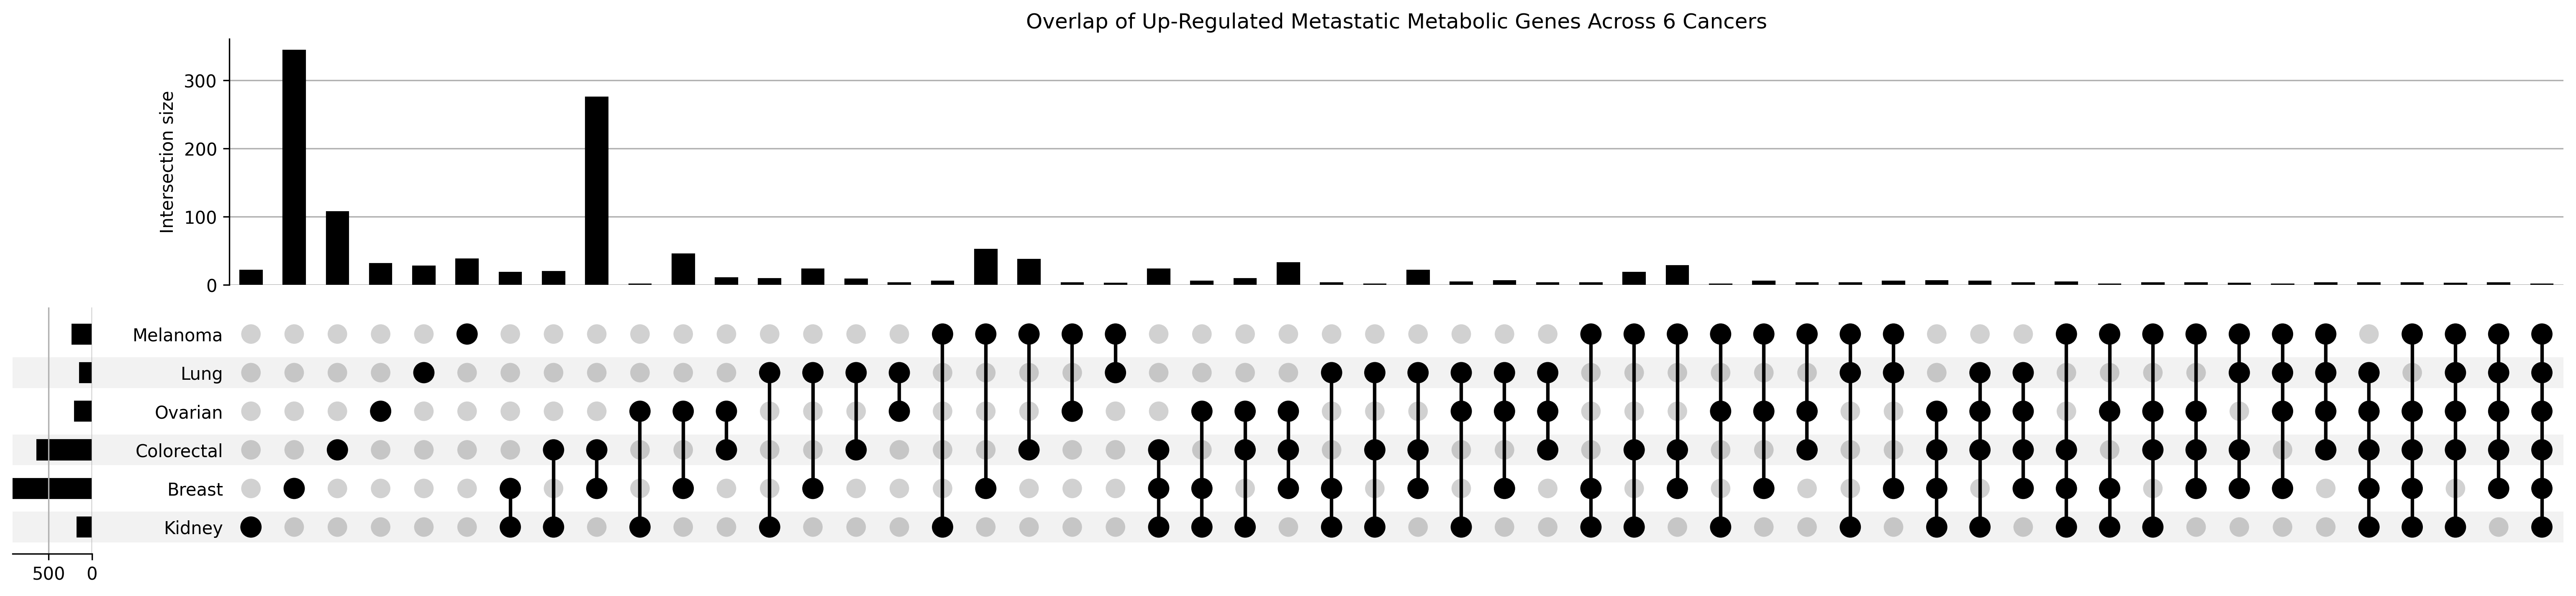

In [ ]:
# 1. Pan-Cancer Overlap (UpSet Plot)
image_path = os.path.join(META_RESULTS_DIR, f'upset_plot{ANALYSIS_SUFFIX}.png')
if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")

print("\nNote: There are exactly 0 genes commonly upregulated across all 6 cancers.")
print("We have relaxed the strict threshold to generate stratified combinations of 5 out of 6 cancers.")


### 2. Conserved Metabolite-Target Network

**Goal:** Map the pan-cancer conserved genes against their interacting metabolites.

**Purpose:** To contextualize these strictly conserved genes into actionable biological pathways and identify highly connected metabolic hubs.

**Inputs / Parameters:**
- **Gene List:** The strictly conserved genes identified in Section 1 (`output/pan_cancer_meta_results/conserved_target_genes.csv`).
- **Database:** `output/human_metab_target_pairs_cancer_annotated.csv` (our merged metabConnectomeDB pairs).

**Underlying Data (CSV):**
- **Network Edges:** `output/pan_cancer_meta_results/metabolite_target_network_edges{ANALYSIS_SUFFIX}.csv` (contains the raw Source-Target edges used to build this visualization).


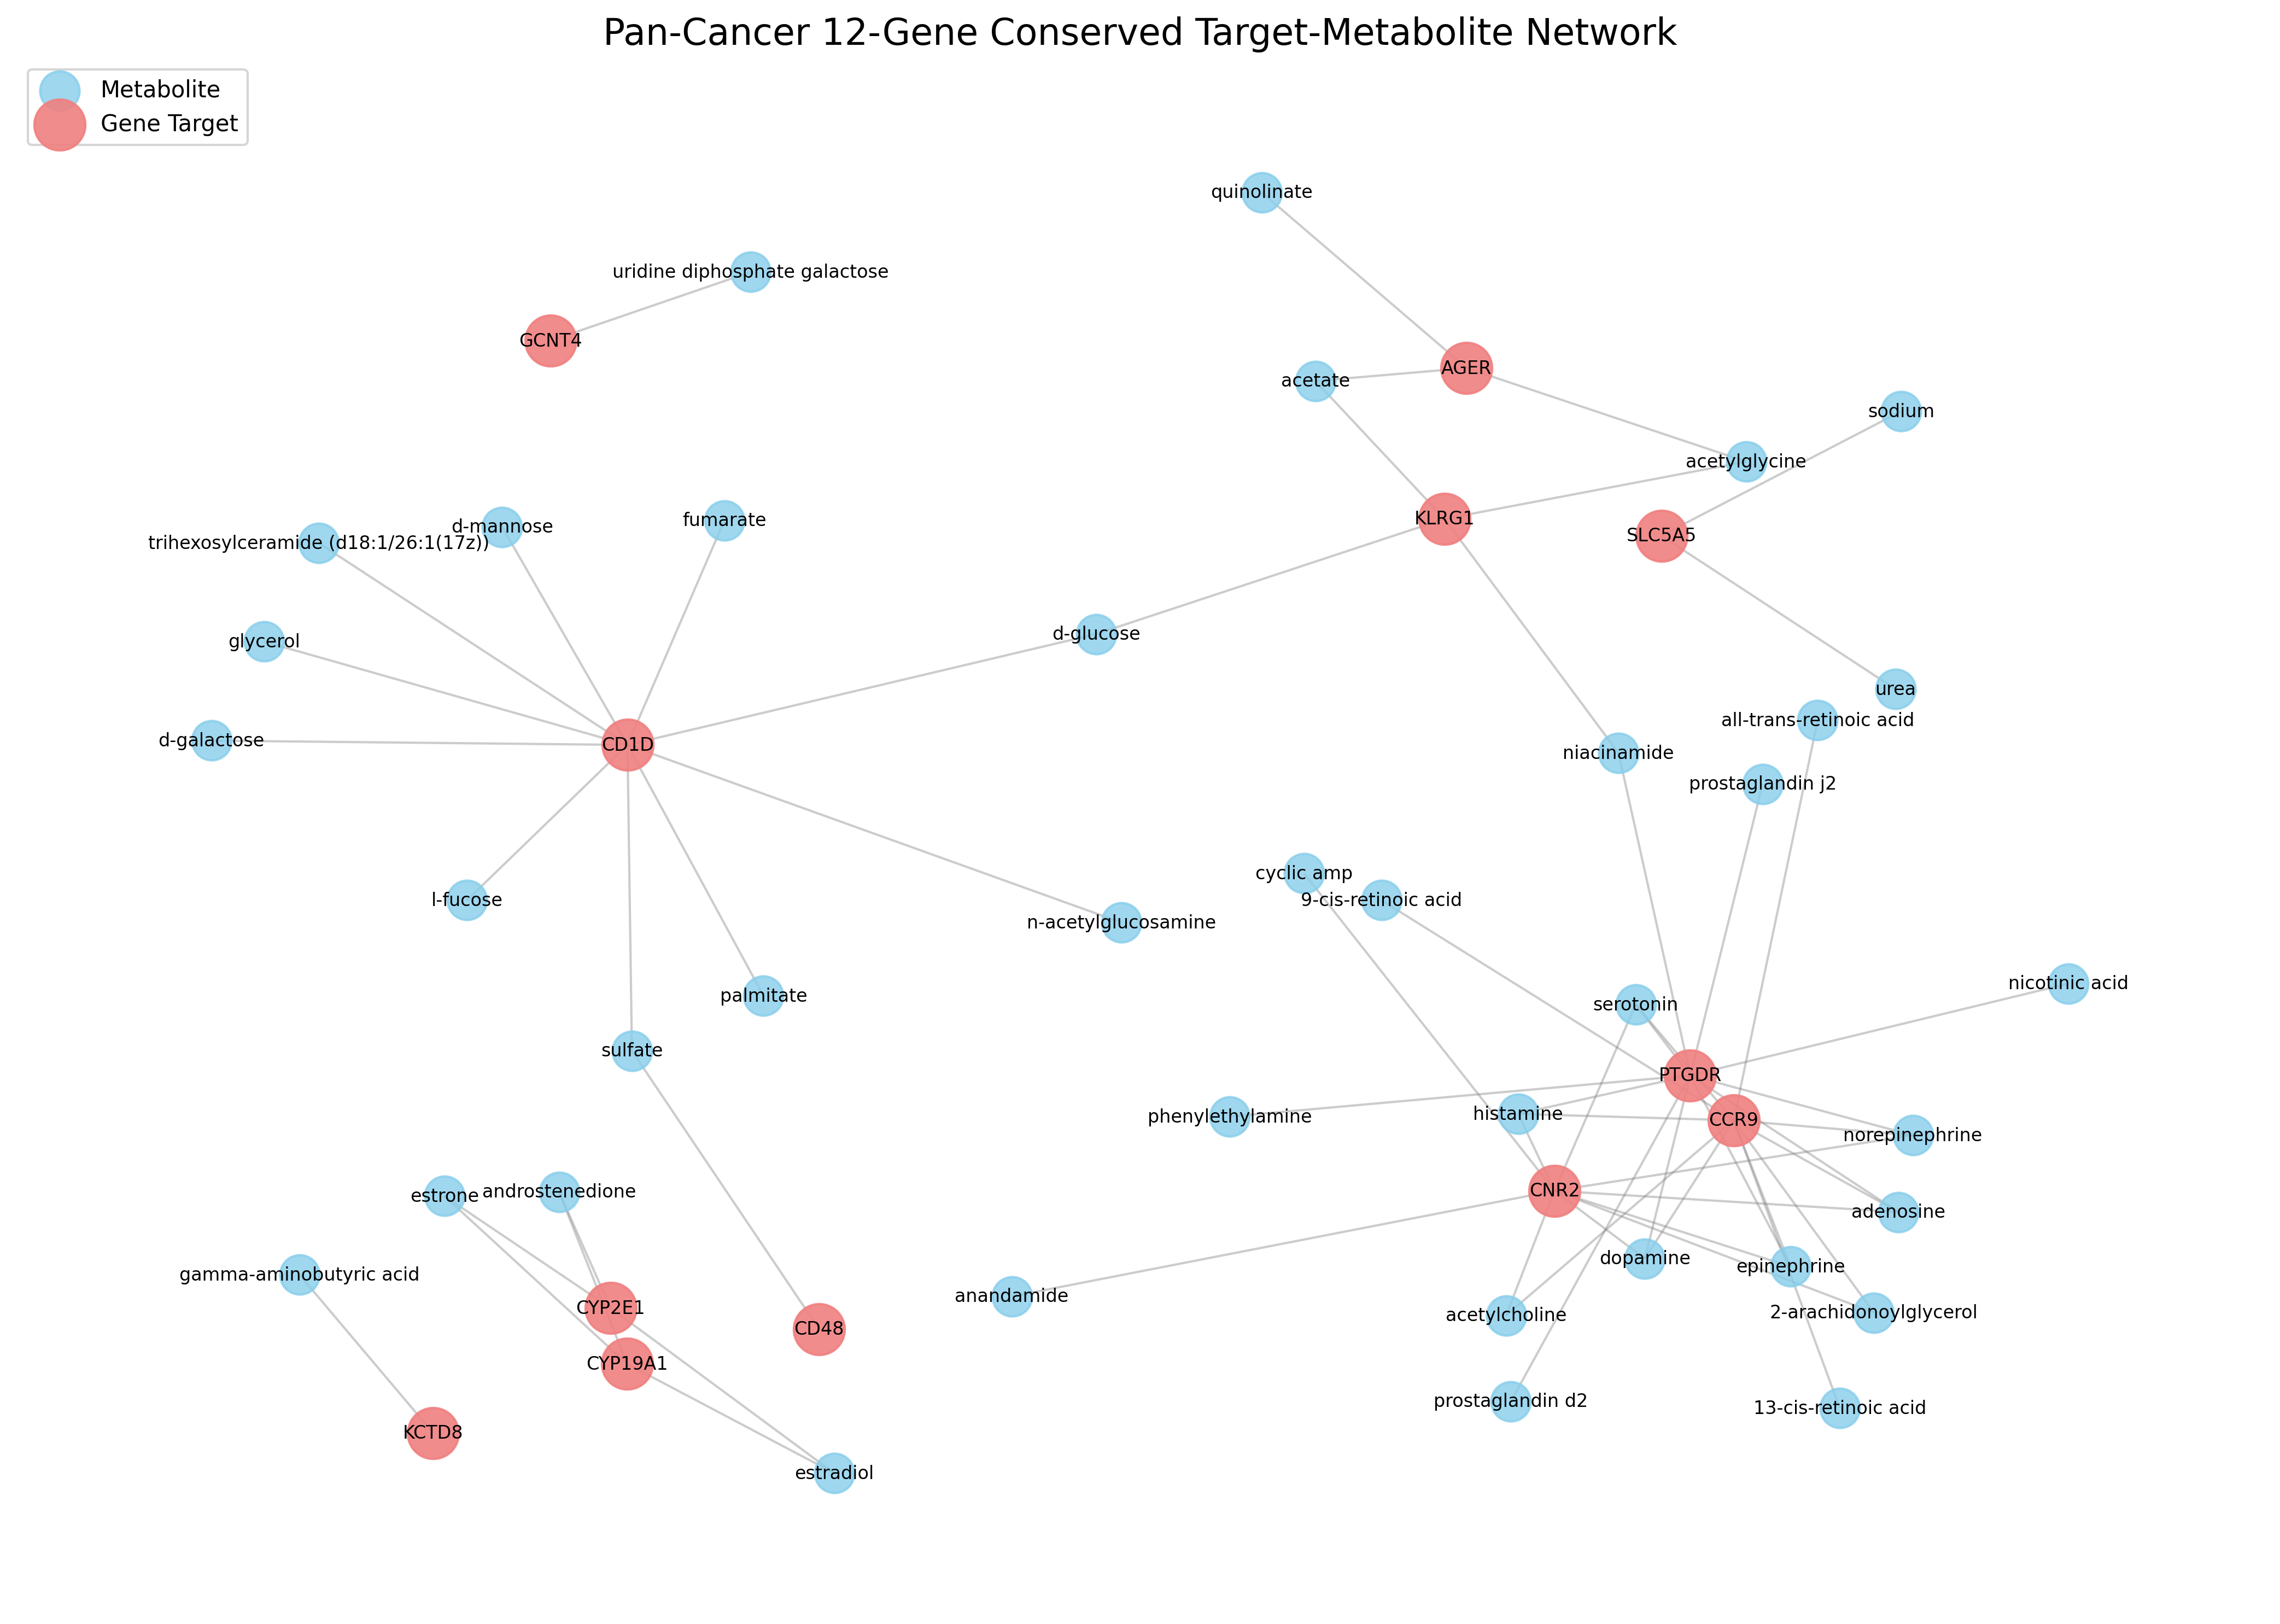

In [ ]:
# 2. Metabolite-Target Network
image_path = os.path.join(META_RESULTS_DIR, f'metabolite_target_network{ANALYSIS_SUFFIX}.png')
if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")


### 3. Predictive Potential of the Conserved Gene Signature

**Goal:** Determine whether the conserved gene signature is heterogeneously expressed in primary tumors.

**Purpose:** To compute a single-cell "Metastatic Metabolic Score" across malignant cells within primary tumors. By identifying a sub-population of primary tumor cells with high expression of this signature, we hypothesize these represent pre-metastatic subclones.

**Interpretation Guide (Distribution Skewness):**
- **Right-Skewed:** Rare, highly active subpopulation (e.g., pre-metastatic subclones).
- **Left-Skewed:** Ubiquitous, pervasive expression across the tumor.
- **Bimodal:** Distinct, competing clones.

**Inputs / Parameters:**
- **Gene Set:** The Conserved Pan-Cancer Genes (`output/pan_cancer_meta_results/conserved_target_genes.csv`).
- **Algorithm:** `scanpy.tl.score_genes()` computes the average expression of the conserved genes subtracted by the average expression of a reference set of randomly sampled genes.
- **Data sources:** The 100k-cell `.h5ad` file for each cancer, explicitly filtered to `cell_type == 'malignant cell'` and subset to the primary tumor `tissue_general`.


#### 3.1 Scoring Primary Breast Cancer Cells
**Underlying Data (CSV):** `output/pan_cancer_meta_results/breast_primary_signature_scores{ANALYSIS_SUFFIX}.csv` (contains cell_id, cell_type, tissue, and Metastatic_Signature_Score for every cell plotted below).



--- Subclone Analysis for Breast ---
Total primary cells: 150852

Signature: Own_Specific_Signature
Top 5% Threshold Score: 0.1047
Identified pre-metastatic subclone cells: 7544

Signature: Conserved Pan-Cancer Signature
Top 5% Threshold Score: 0.0472
Identified pre-metastatic subclone cells: 7654


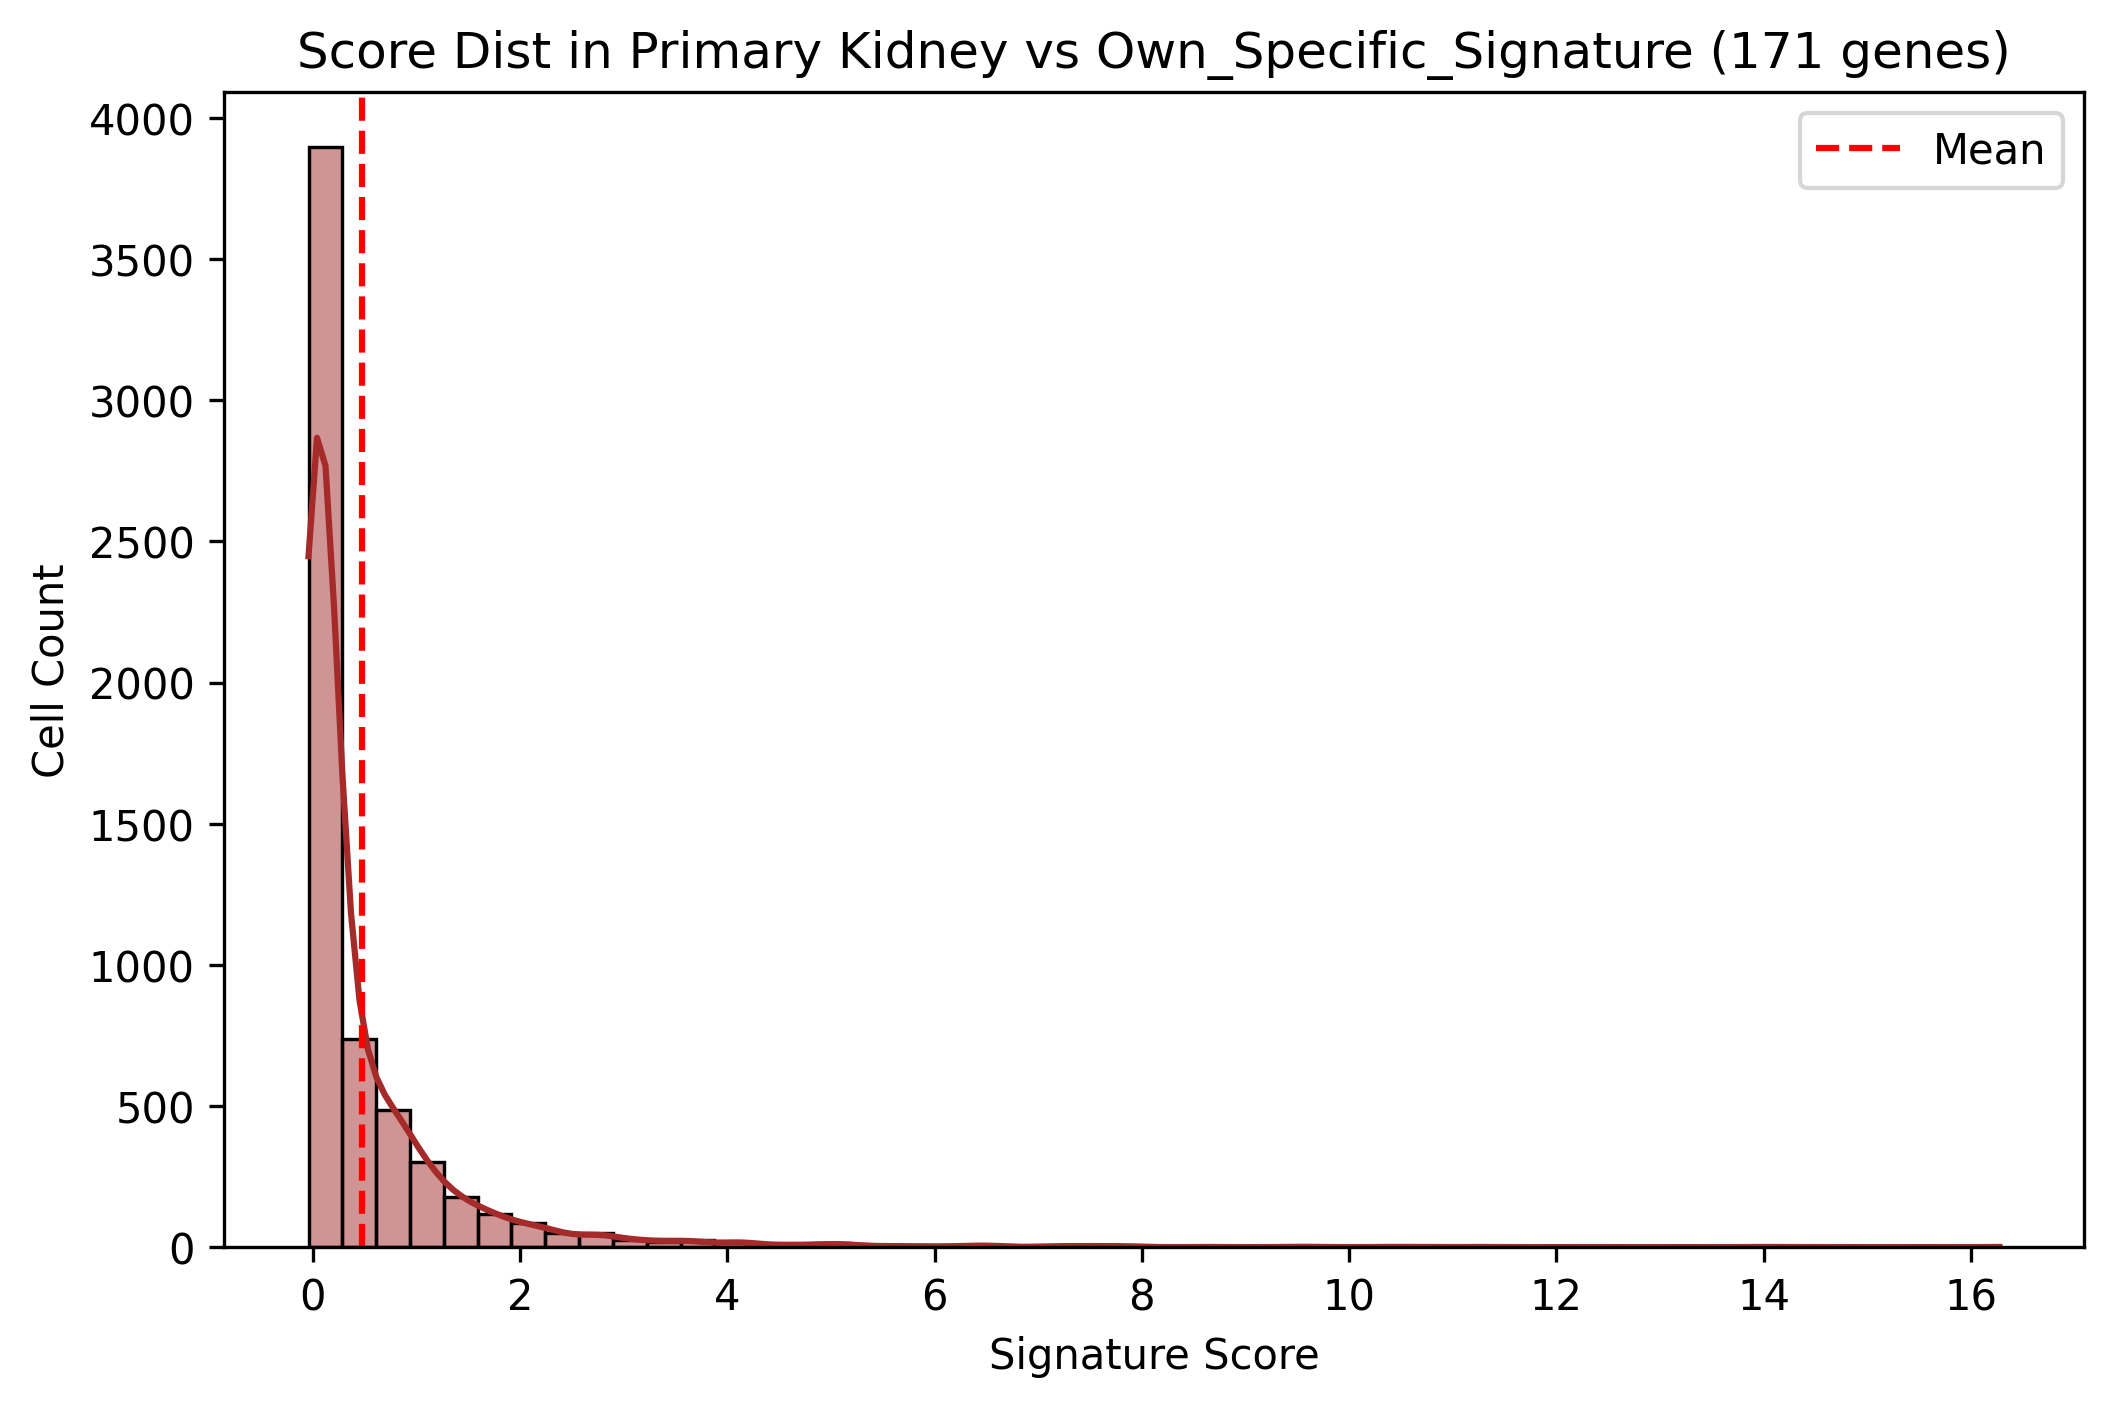

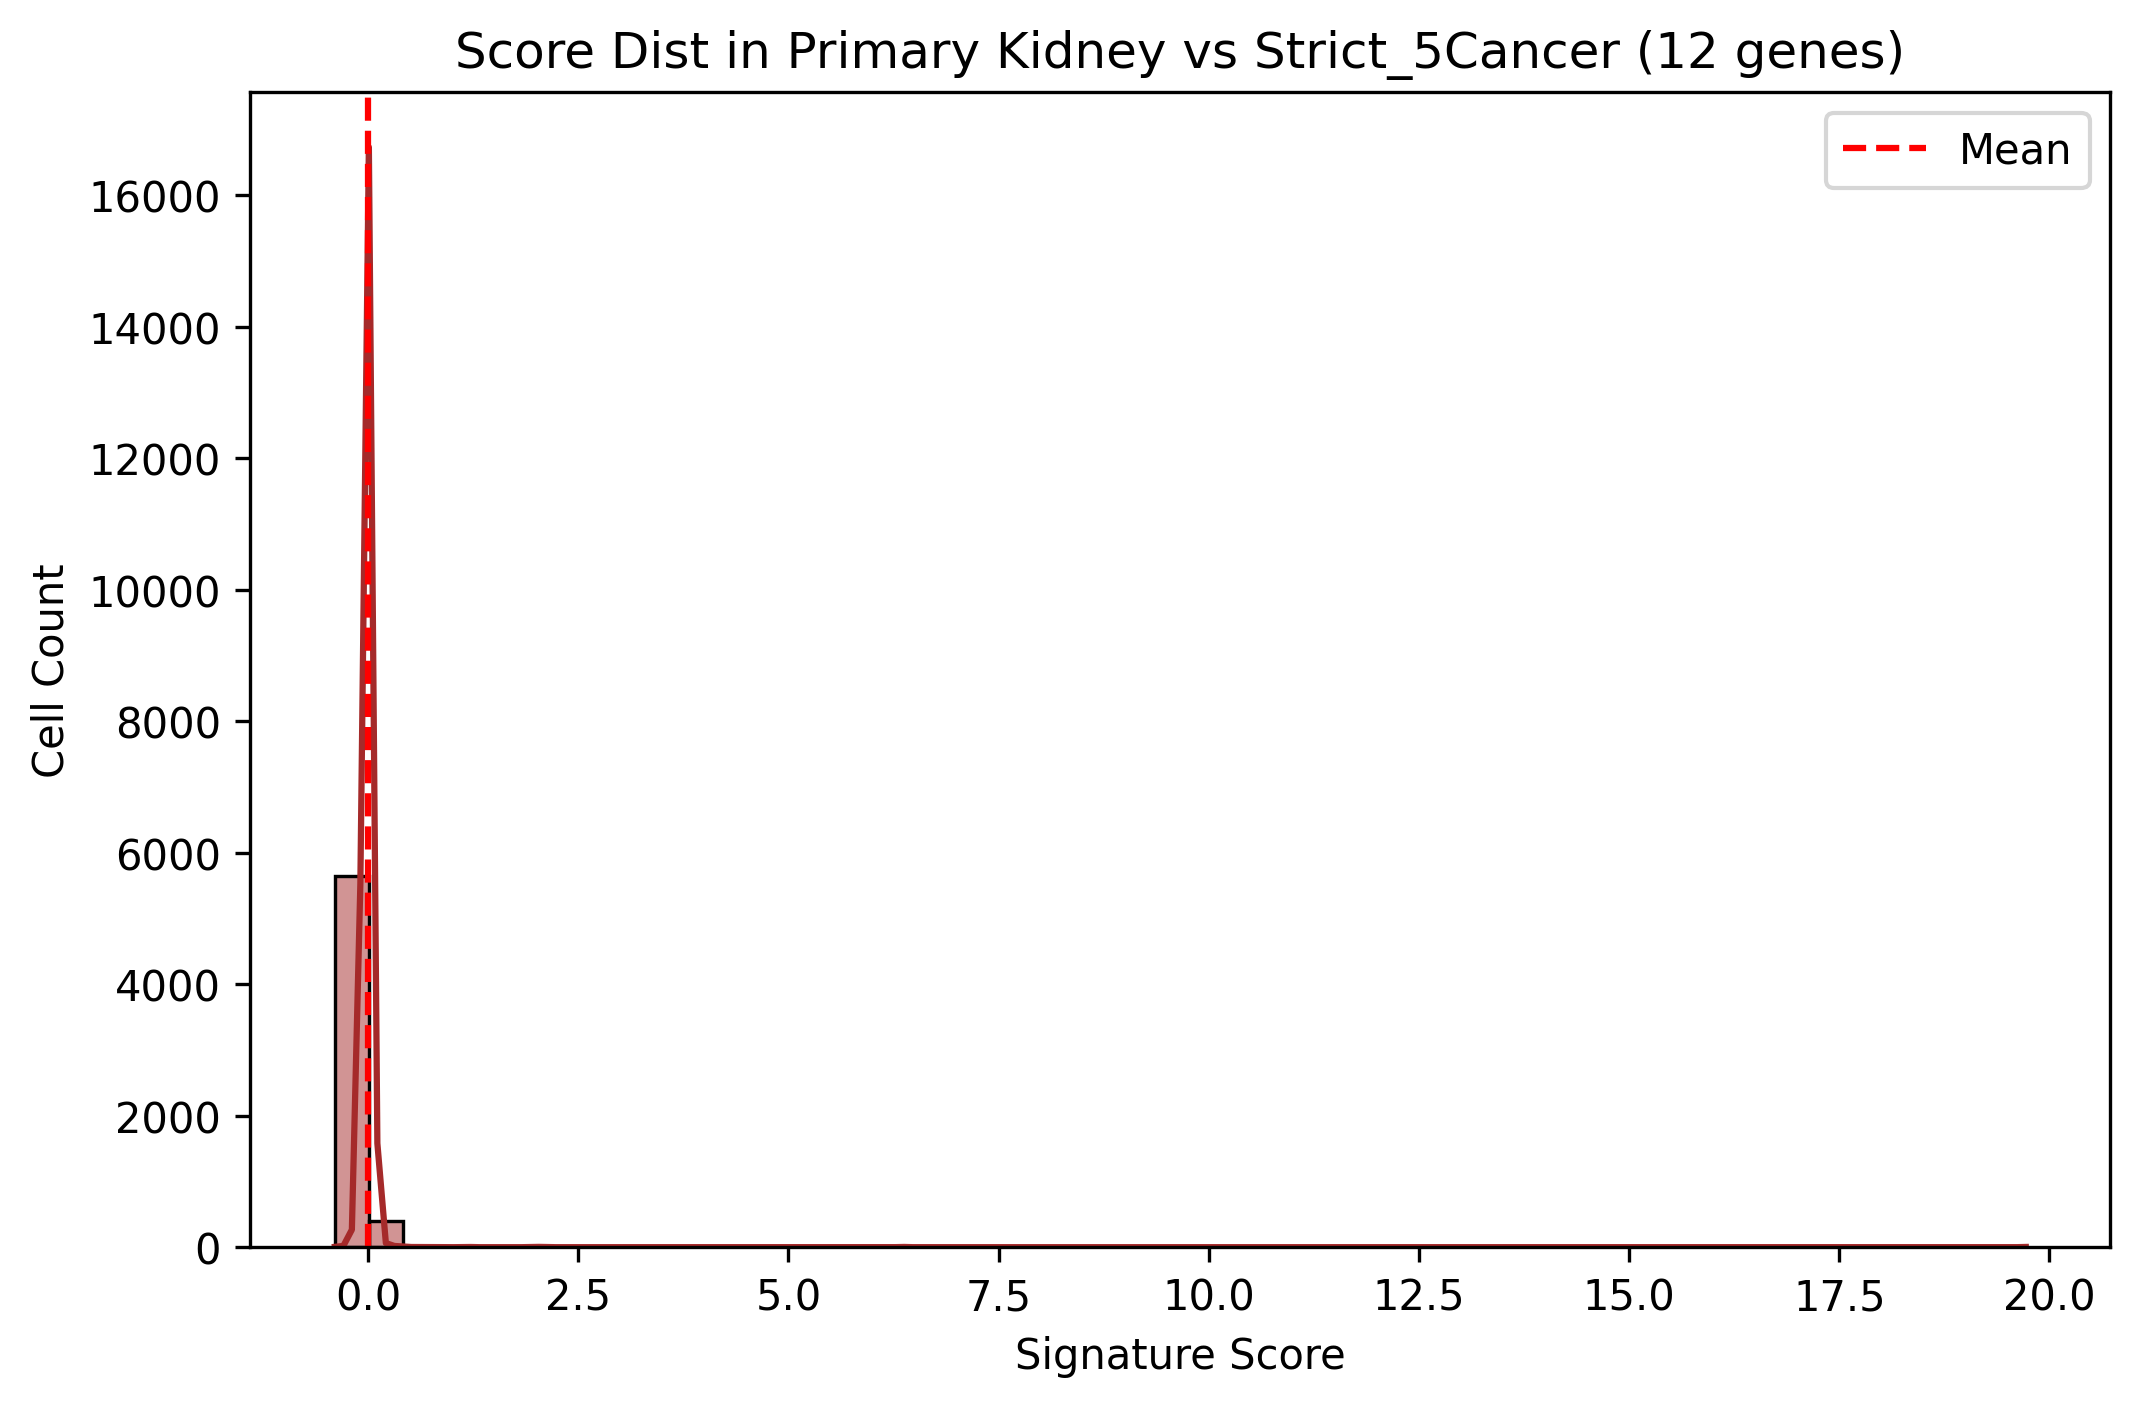

In [ ]:
# 3.1 Breast Cancer
import glob
image_paths = glob.glob(os.path.join(META_RESULTS_DIR, f'kidney_primary_score_*.png'))
if not image_paths:
    print(f"Warning: No signature score images found for Breast.")
else:
    for ipath in image_paths:
        display(Image(filename=ipath))

# Apply paper recommendations: Identify the rare pre-metastatic subclone using top 5% quantile thresholding
csv_path = os.path.join(META_RESULTS_DIR, f'breast_primary_signature_scores{ANALYSIS_SUFFIX}.csv')
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Missing required underlying data CSV: {csv_path}")

df = pd.read_csv(csv_path)

score_cols = [c for c in df.columns if c.startswith('Metastatic_Signature_Score')]
if not score_cols:
    raise ValueError("Missing any 'Metastatic_Signature_Score' columns in CSV data")

print(f"\n--- Subclone Analysis for Breast ---")
print(f"Total primary cells: {len(df)}")

for col in score_cols:
    # Avoid hardcoding by calculating threshold computationally
    threshold = df[col].quantile(0.95)
    subclone_df = df[df[col] >= threshold]
    signature_name = col.replace('Metastatic_Signature_Score_', '')
    if signature_name == 'Metastatic_Signature_Score':
        signature_name = 'Conserved Pan-Cancer Signature'
    print(f"\nSignature: {signature_name}")
    print(f"Top 5% Threshold Score: {threshold:.4f}")
    print(f"Identified pre-metastatic subclone cells: {len(subclone_df)}")


#### 3.2 Scoring Primary Colorectal Cancer Cells
**Underlying Data (CSV):** `output/pan_cancer_meta_results/colorectal_primary_signature_scores{ANALYSIS_SUFFIX}.csv` (contains cell_id, cell_type, tissue, and Metastatic_Signature_Score for every cell plotted below).



--- Subclone Analysis for Colorectal ---
Total primary cells: 14647

Signature: Own_Specific_Signature
Top 5% Threshold Score: 0.0586
Identified pre-metastatic subclone cells: 733

Signature: Conserved Pan-Cancer Signature
Top 5% Threshold Score: 0.0713
Identified pre-metastatic subclone cells: 759


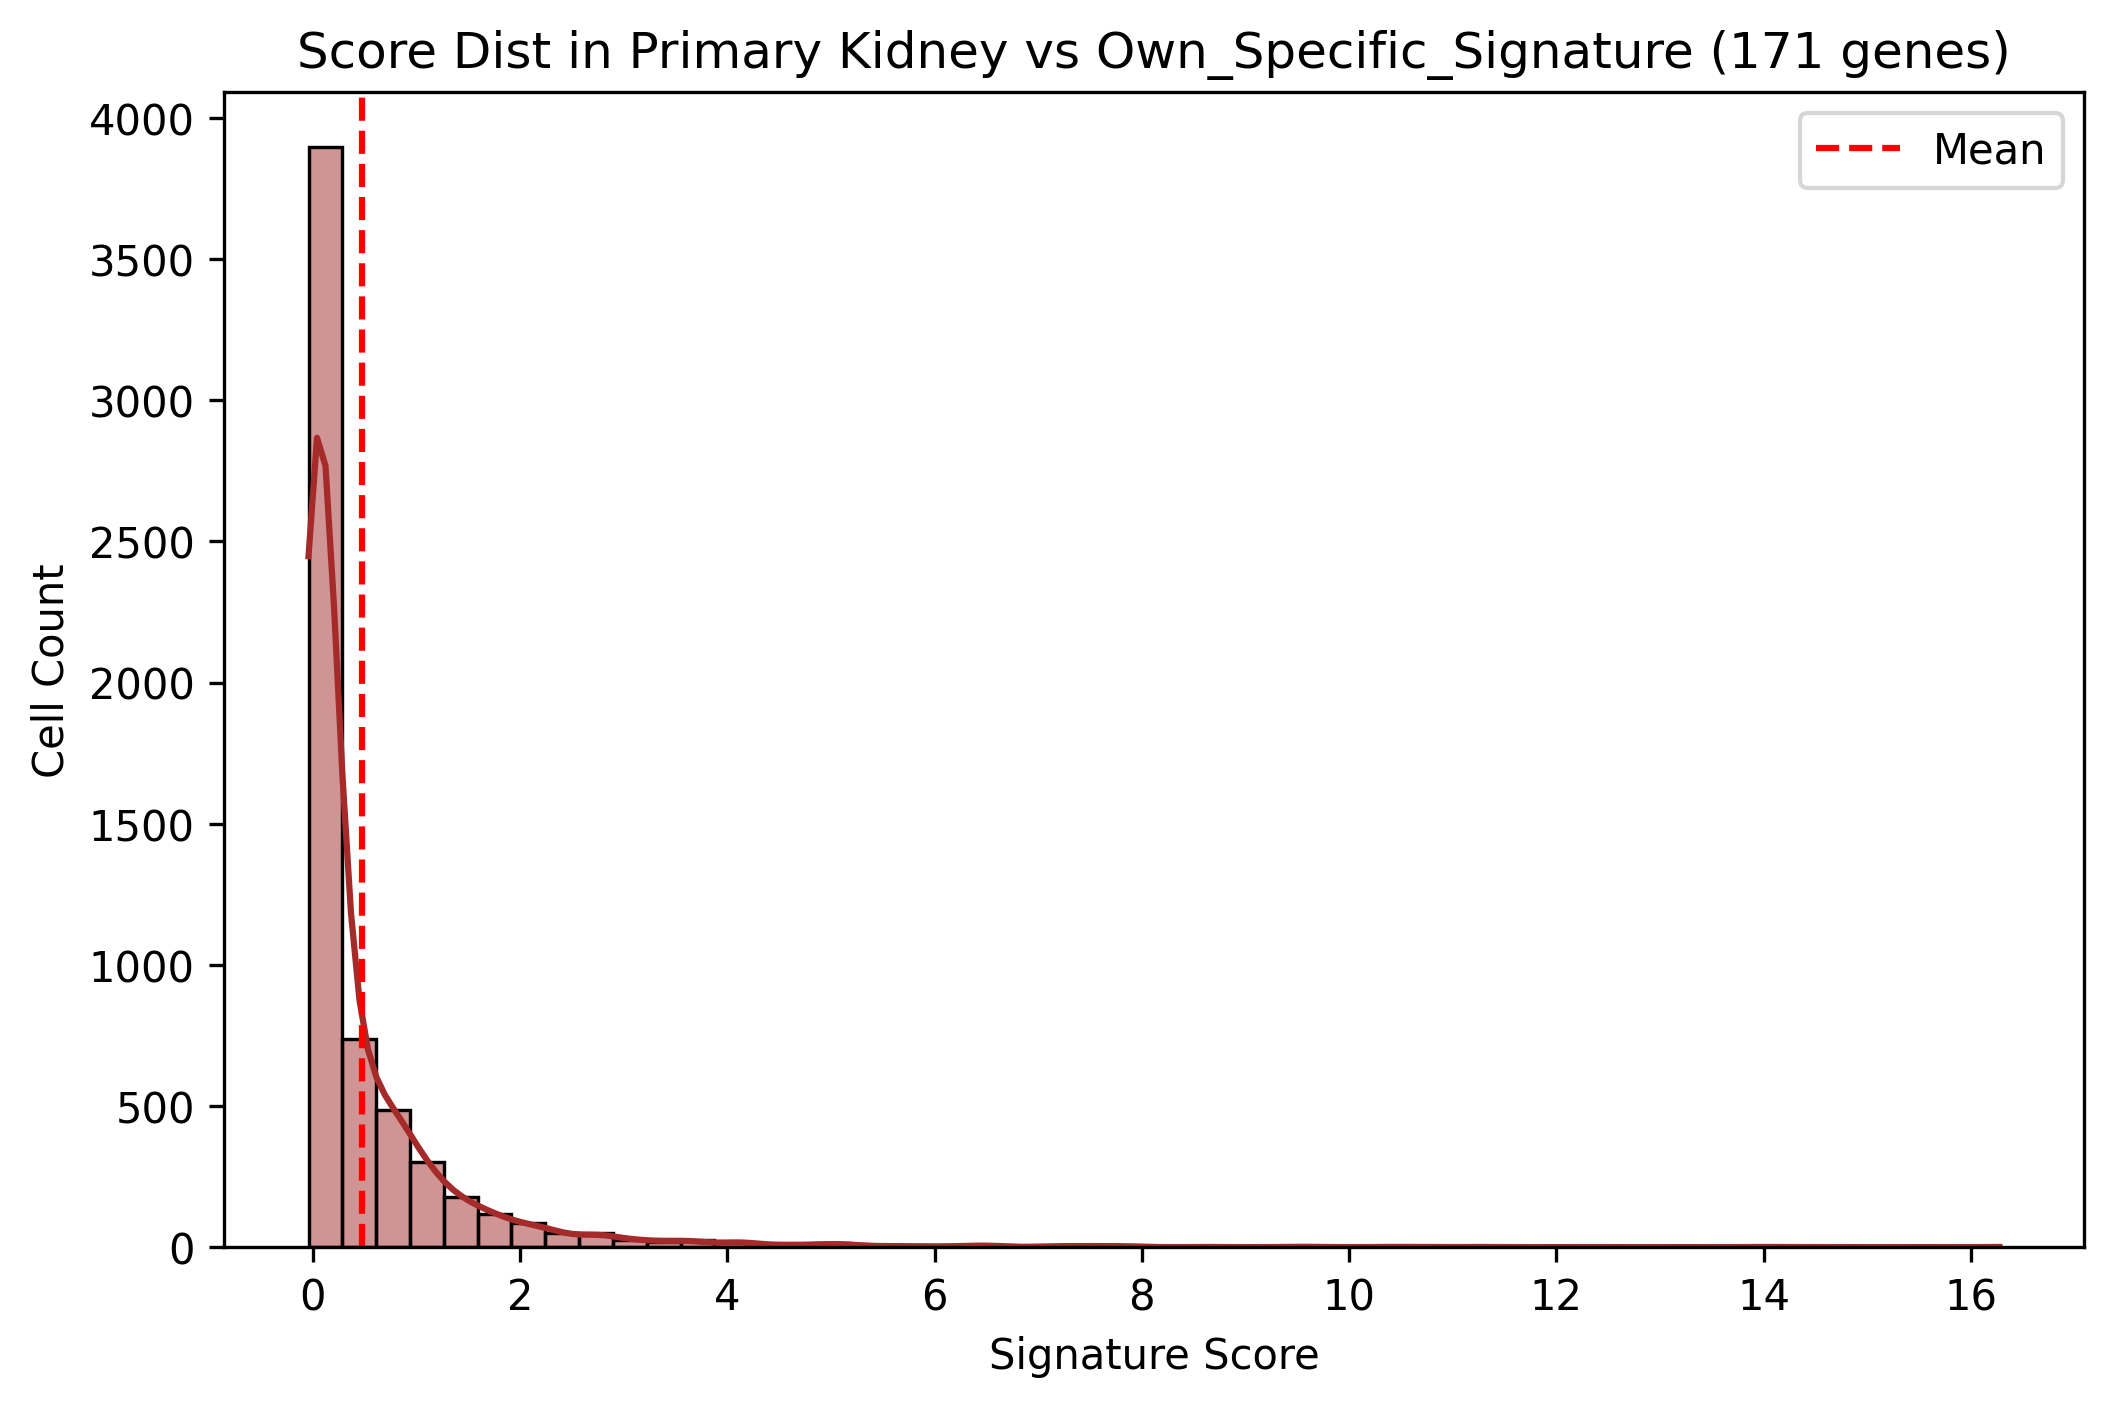

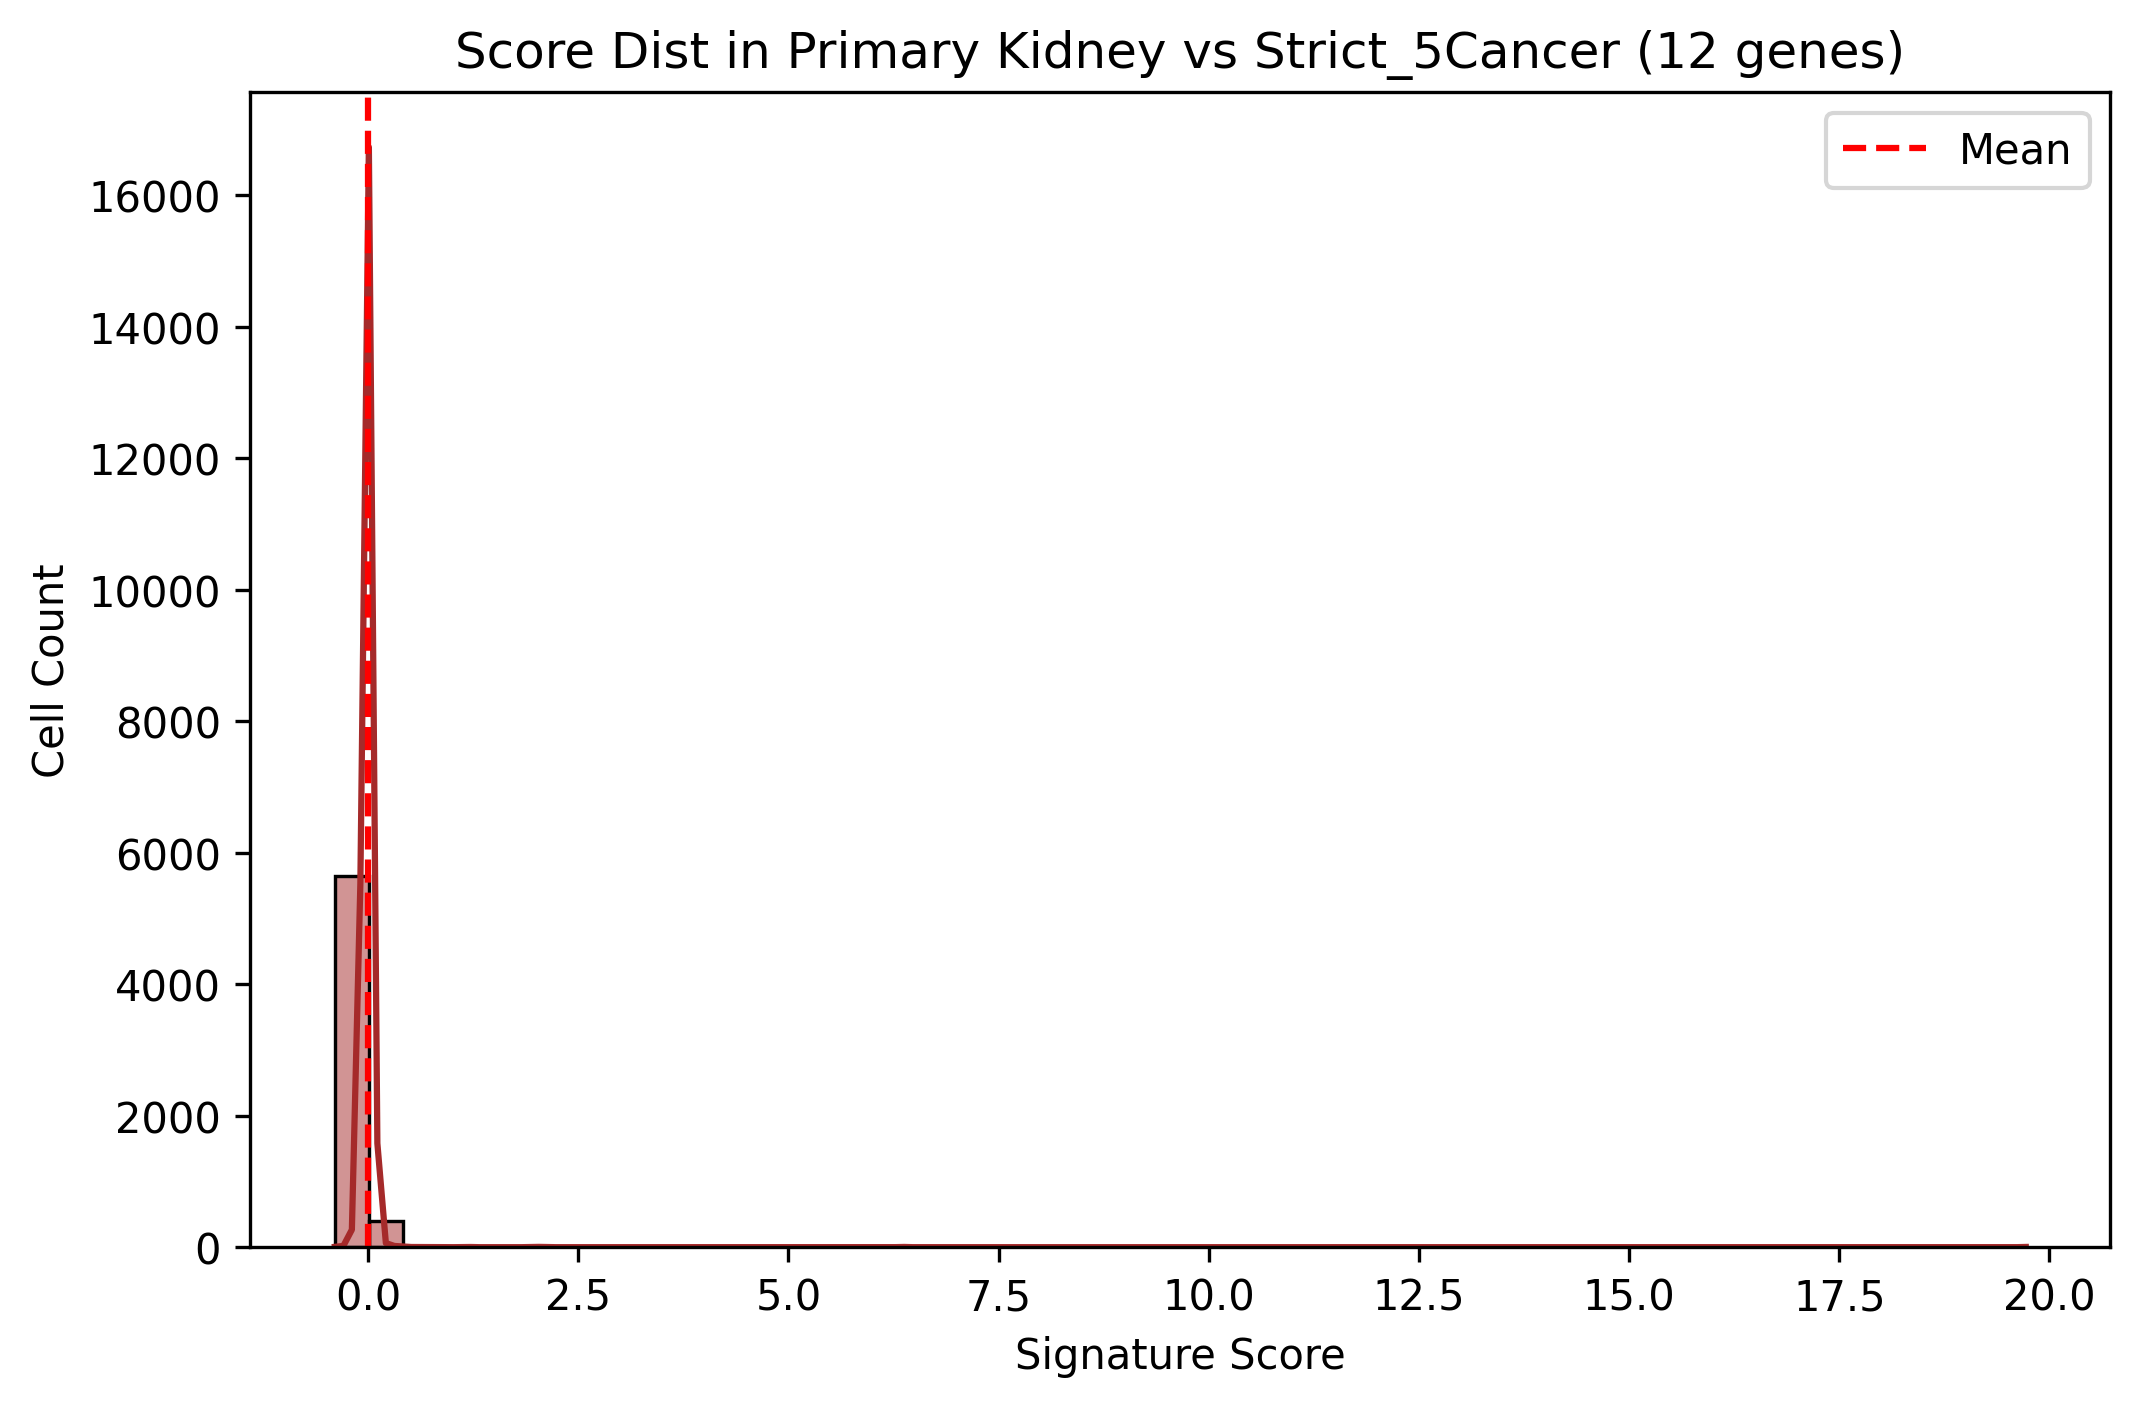

In [ ]:
# 3.2 Colorectal Cancer
import glob
image_paths = glob.glob(os.path.join(META_RESULTS_DIR, f'kidney_primary_score_*.png'))
if not image_paths:
    print(f"Warning: No signature score images found for Colorectal.")
else:
    for ipath in image_paths:
        display(Image(filename=ipath))

# Apply paper recommendations: Identify the rare pre-metastatic subclone using top 5% quantile thresholding
csv_path = os.path.join(META_RESULTS_DIR, f'colorectal_primary_signature_scores{ANALYSIS_SUFFIX}.csv')
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Missing required underlying data CSV: {csv_path}")

df = pd.read_csv(csv_path)

score_cols = [c for c in df.columns if c.startswith('Metastatic_Signature_Score')]
if not score_cols:
    raise ValueError("Missing any 'Metastatic_Signature_Score' columns in CSV data")

print(f"\n--- Subclone Analysis for Colorectal ---")
print(f"Total primary cells: {len(df)}")

for col in score_cols:
    # Avoid hardcoding by calculating threshold computationally
    threshold = df[col].quantile(0.95)
    subclone_df = df[df[col] >= threshold]
    signature_name = col.replace('Metastatic_Signature_Score_', '')
    if signature_name == 'Metastatic_Signature_Score':
        signature_name = 'Conserved Pan-Cancer Signature'
    print(f"\nSignature: {signature_name}")
    print(f"Top 5% Threshold Score: {threshold:.4f}")
    print(f"Identified pre-metastatic subclone cells: {len(subclone_df)}")


#### 3.3 Scoring Primary Lung Cancer Cells
**Underlying Data (CSV):** `output/pan_cancer_meta_results/lung_primary_signature_scores{ANALYSIS_SUFFIX}.csv` (contains cell_id, cell_type, tissue, and Metastatic_Signature_Score for every cell plotted below).



--- Subclone Analysis for Lung ---
Total primary cells: 19498

Signature: Own_Specific_Signature
Top 5% Threshold Score: 0.7243
Identified pre-metastatic subclone cells: 975

Signature: Conserved Pan-Cancer Signature
Top 5% Threshold Score: -0.0161
Identified pre-metastatic subclone cells: 988


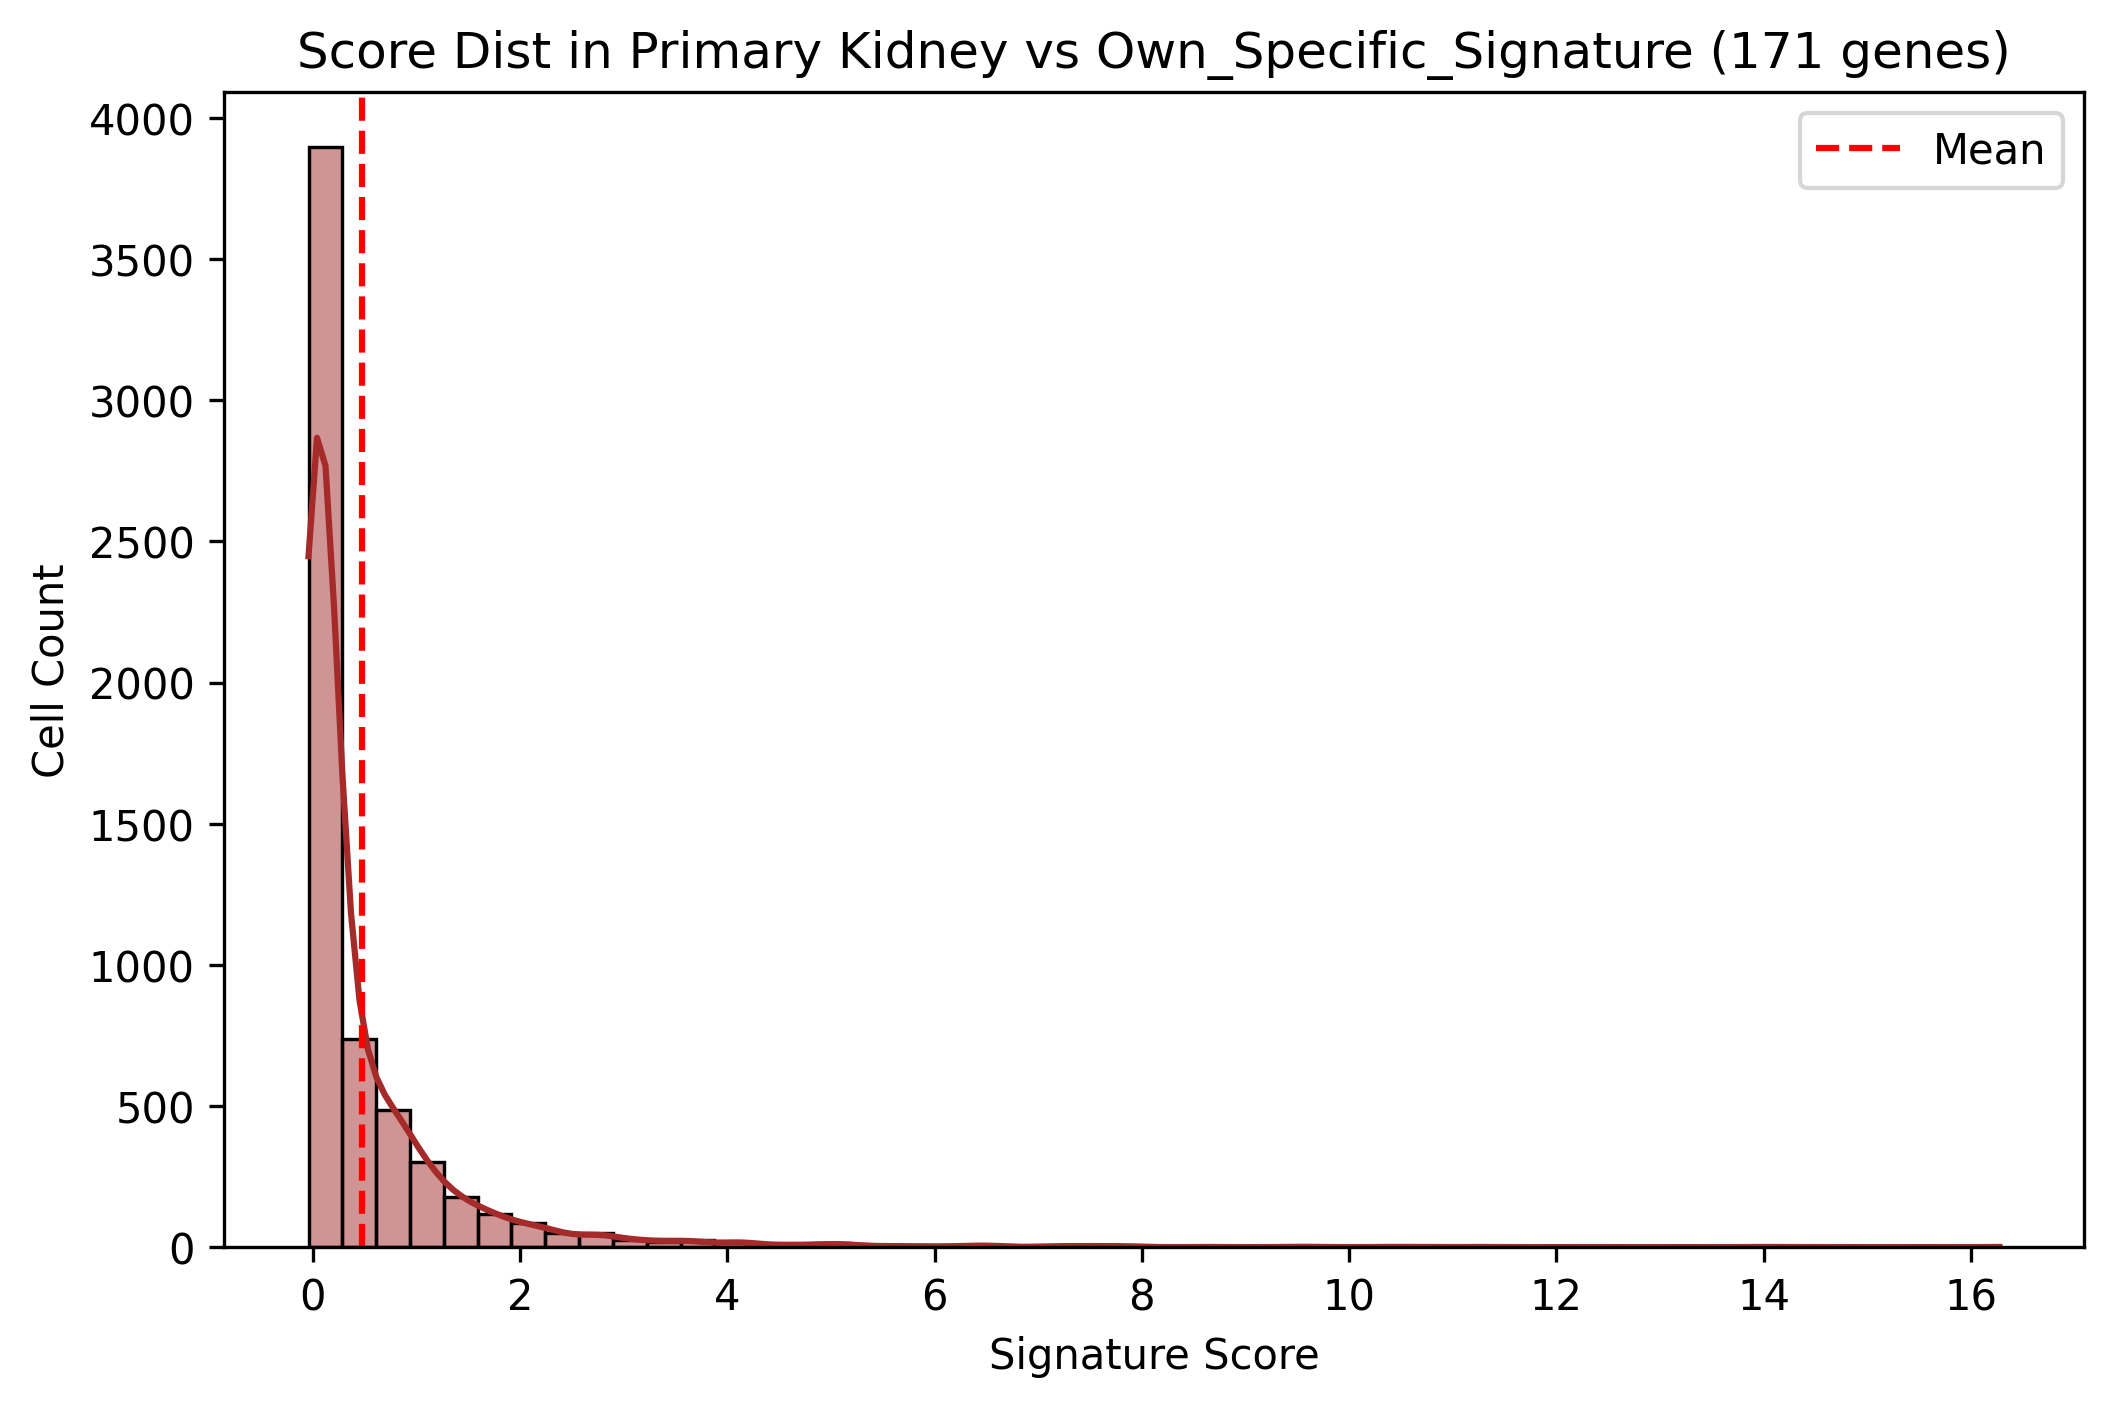

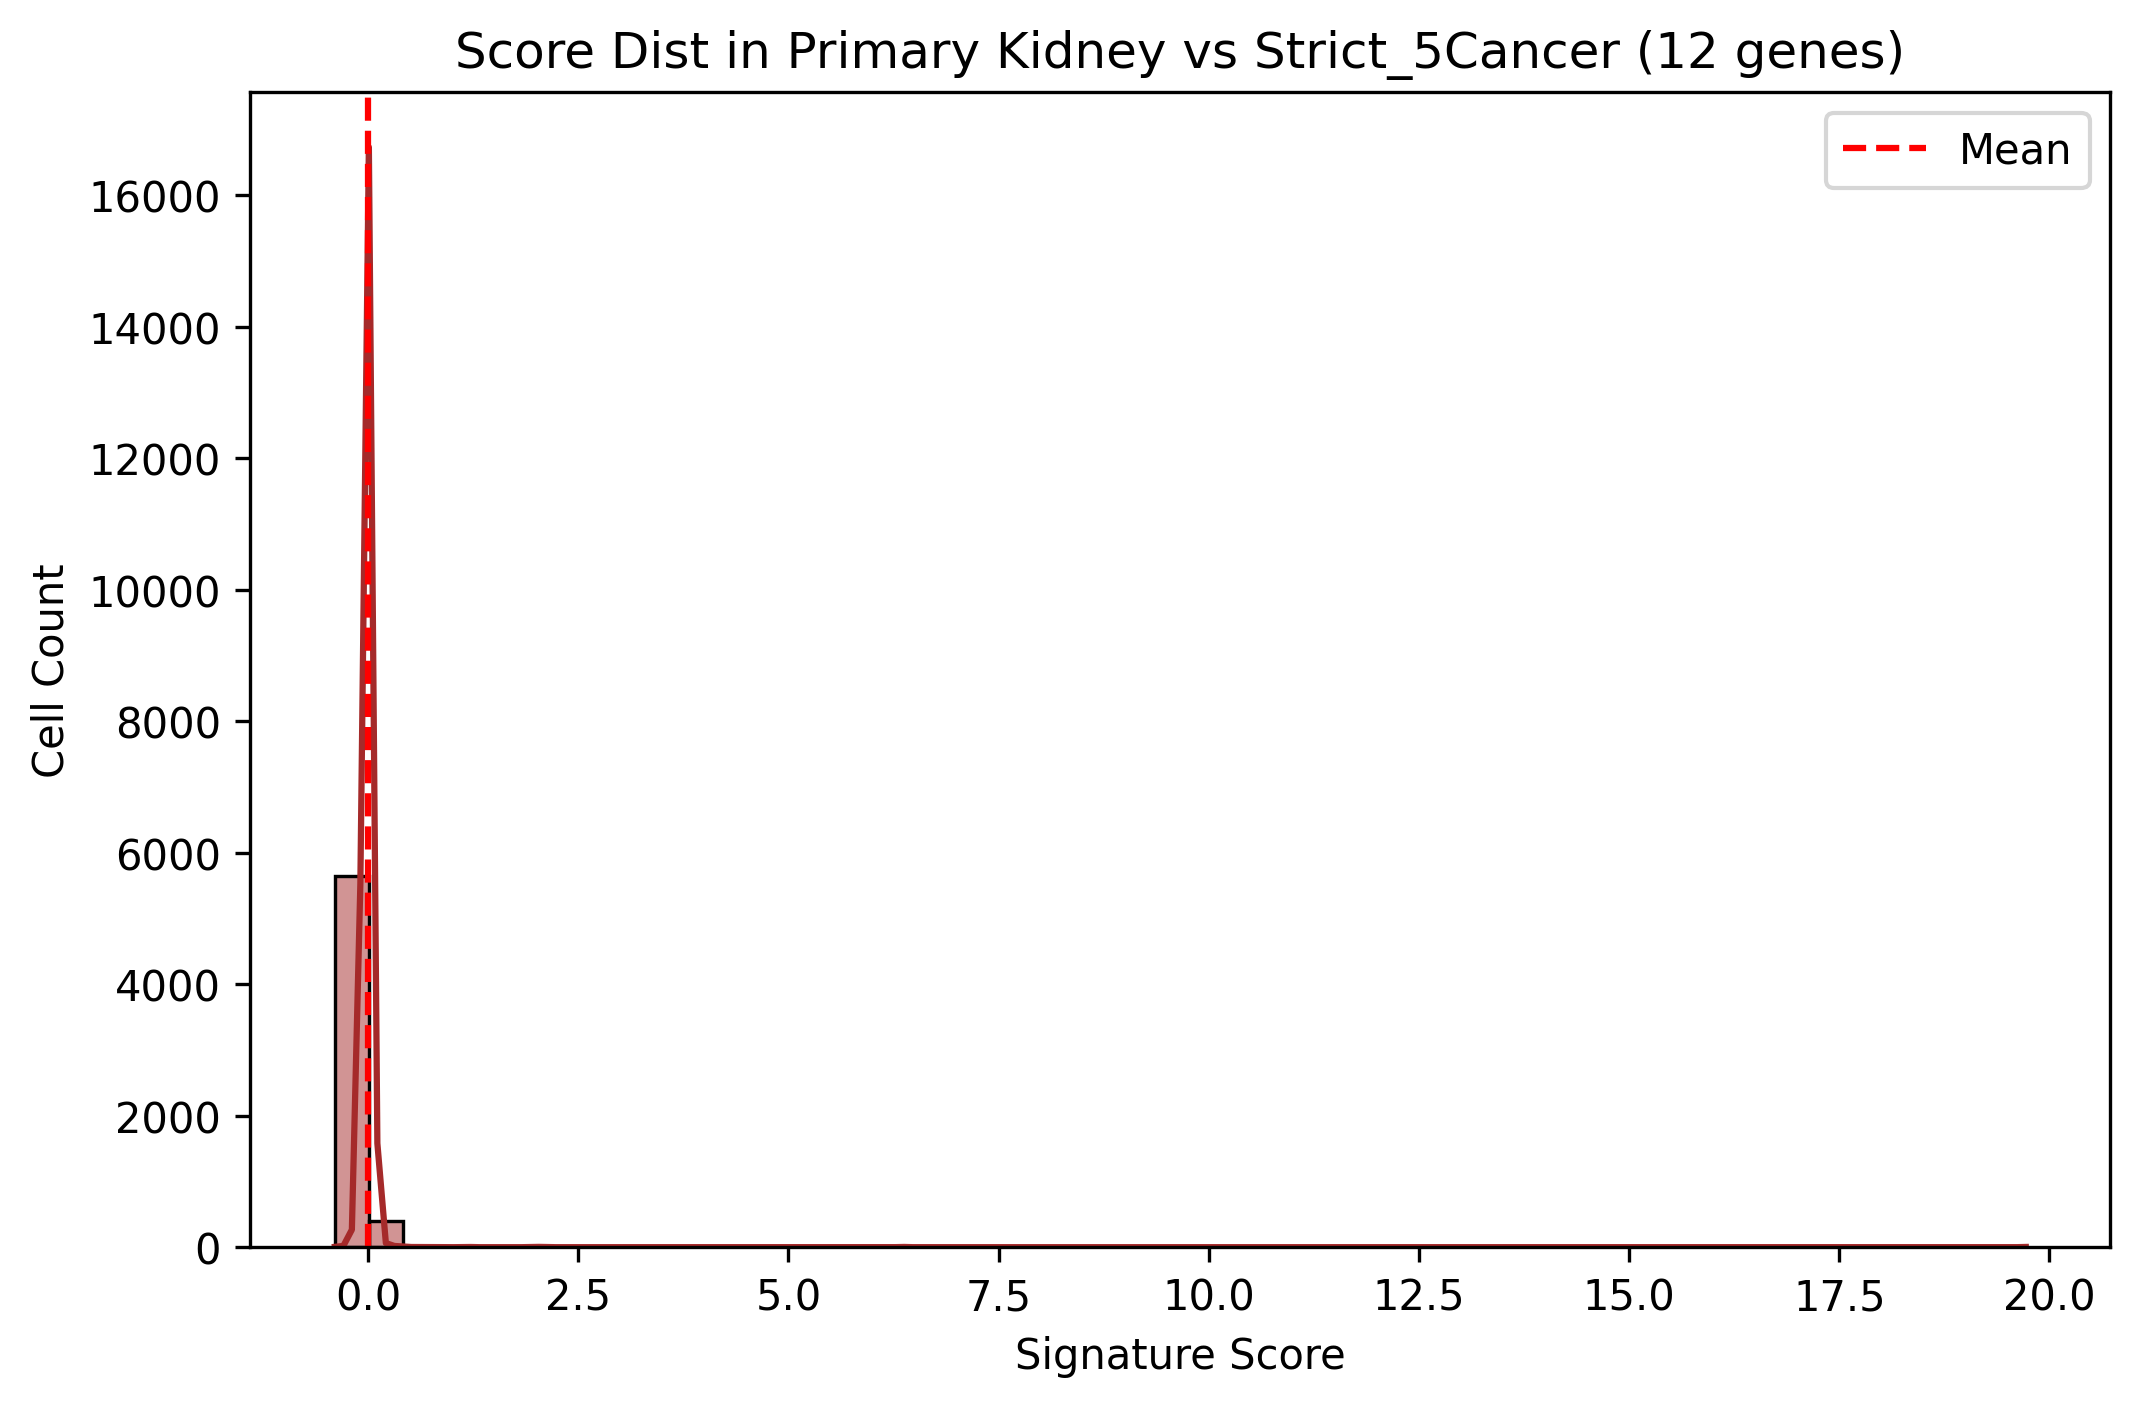

In [ ]:
# 3.3 Lung Cancer
import glob
image_paths = glob.glob(os.path.join(META_RESULTS_DIR, f'kidney_primary_score_*.png'))
if not image_paths:
    print(f"Warning: No signature score images found for Lung.")
else:
    for ipath in image_paths:
        display(Image(filename=ipath))

# Apply paper recommendations: Identify the rare pre-metastatic subclone using top 5% quantile thresholding
csv_path = os.path.join(META_RESULTS_DIR, f'lung_primary_signature_scores{ANALYSIS_SUFFIX}.csv')
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Missing required underlying data CSV: {csv_path}")

df = pd.read_csv(csv_path)

score_cols = [c for c in df.columns if c.startswith('Metastatic_Signature_Score')]
if not score_cols:
    raise ValueError("Missing any 'Metastatic_Signature_Score' columns in CSV data")

print(f"\n--- Subclone Analysis for Lung ---")
print(f"Total primary cells: {len(df)}")

for col in score_cols:
    # Avoid hardcoding by calculating threshold computationally
    threshold = df[col].quantile(0.95)
    subclone_df = df[df[col] >= threshold]
    signature_name = col.replace('Metastatic_Signature_Score_', '')
    if signature_name == 'Metastatic_Signature_Score':
        signature_name = 'Conserved Pan-Cancer Signature'
    print(f"\nSignature: {signature_name}")
    print(f"Top 5% Threshold Score: {threshold:.4f}")
    print(f"Identified pre-metastatic subclone cells: {len(subclone_df)}")


#### 3.4 Scoring Primary Melanoma Cancer Cells
**Underlying Data (CSV):** `output/pan_cancer_meta_results/melanoma_primary_signature_scores{ANALYSIS_SUFFIX}.csv` (contains cell_id, cell_type, tissue, and Metastatic_Signature_Score for every cell plotted below).



--- Subclone Analysis for Melanoma ---
Total primary cells: 10992

Signature: Own_Specific_Signature
Top 5% Threshold Score: 5.1595
Identified pre-metastatic subclone cells: 550

Signature: Conserved Pan-Cancer Signature
Top 5% Threshold Score: 0.1315
Identified pre-metastatic subclone cells: 562


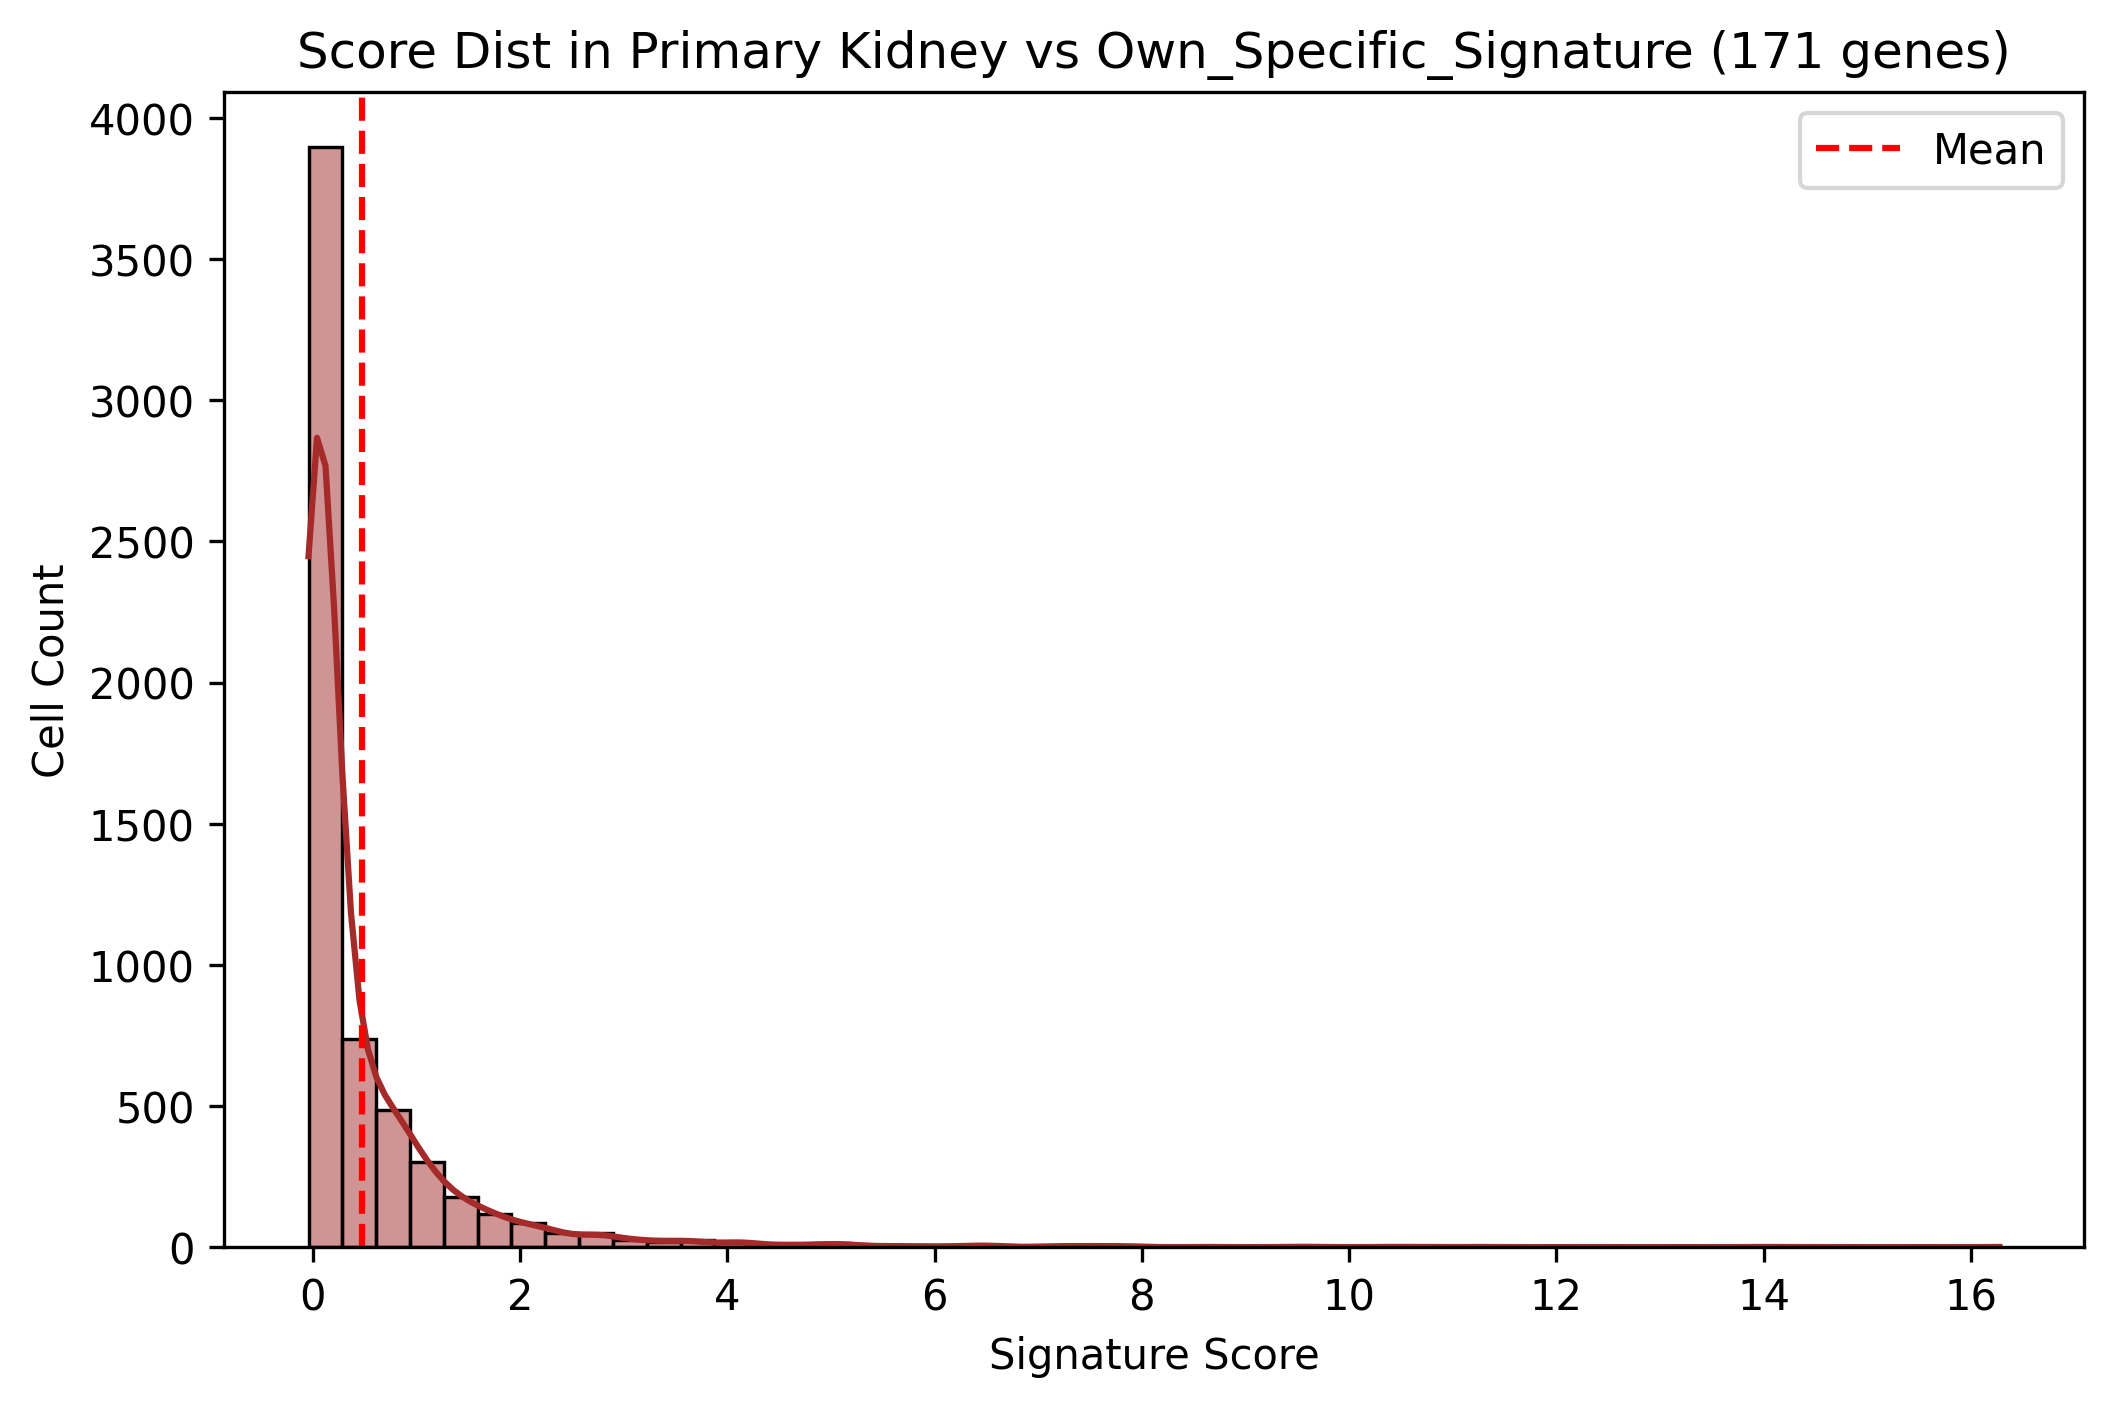

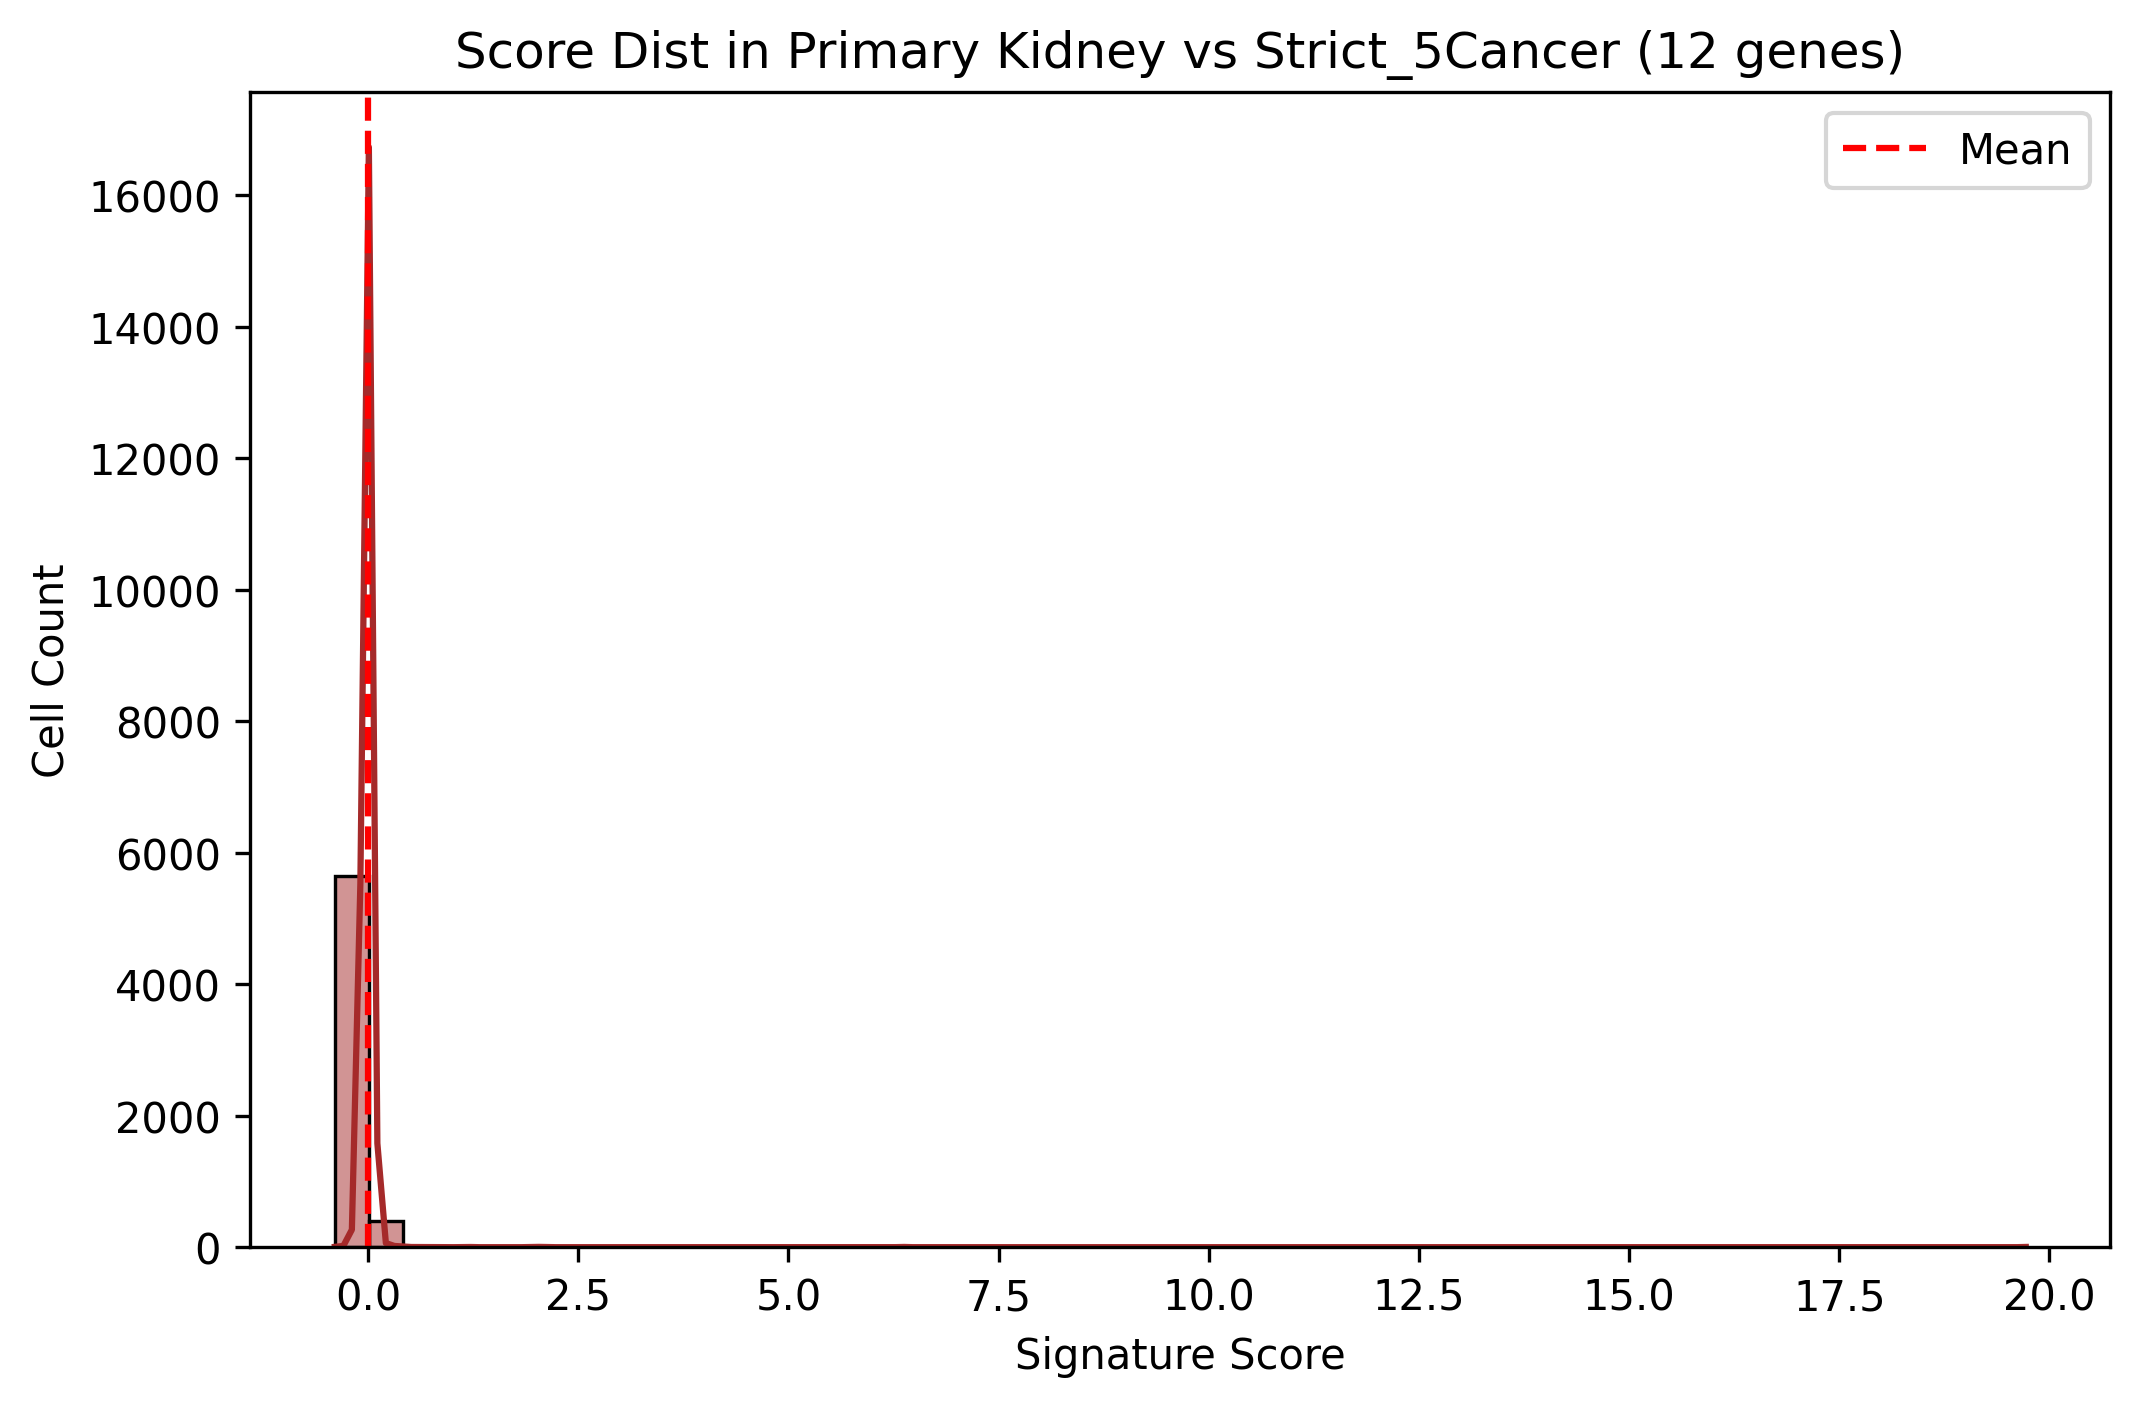

In [ ]:
# 3.4 Melanoma Cancer
import glob
image_paths = glob.glob(os.path.join(META_RESULTS_DIR, f'kidney_primary_score_*.png'))
if not image_paths:
    print(f"Warning: No signature score images found for Melanoma.")
else:
    for ipath in image_paths:
        display(Image(filename=ipath))

# Apply paper recommendations: Identify the rare pre-metastatic subclone using top 5% quantile thresholding
csv_path = os.path.join(META_RESULTS_DIR, f'melanoma_primary_signature_scores{ANALYSIS_SUFFIX}.csv')
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Missing required underlying data CSV: {csv_path}")

df = pd.read_csv(csv_path)

score_cols = [c for c in df.columns if c.startswith('Metastatic_Signature_Score')]
if not score_cols:
    raise ValueError("Missing any 'Metastatic_Signature_Score' columns in CSV data")

print(f"\n--- Subclone Analysis for Melanoma ---")
print(f"Total primary cells: {len(df)}")

for col in score_cols:
    # Avoid hardcoding by calculating threshold computationally
    threshold = df[col].quantile(0.95)
    subclone_df = df[df[col] >= threshold]
    signature_name = col.replace('Metastatic_Signature_Score_', '')
    if signature_name == 'Metastatic_Signature_Score':
        signature_name = 'Conserved Pan-Cancer Signature'
    print(f"\nSignature: {signature_name}")
    print(f"Top 5% Threshold Score: {threshold:.4f}")
    print(f"Identified pre-metastatic subclone cells: {len(subclone_df)}")


#### 3.5 Scoring Primary Ovarian Cancer Cells
**Underlying Data (CSV):** `output/pan_cancer_meta_results/ovarian_primary_signature_scores{ANALYSIS_SUFFIX}.csv` (contains cell_id, cell_type, tissue, and Metastatic_Signature_Score for every cell plotted below).



--- Subclone Analysis for Ovarian ---
Total primary cells: 7611

Signature: Own_Specific_Signature
Top 5% Threshold Score: 0.0383
Identified pre-metastatic subclone cells: 383

Signature: Conserved Pan-Cancer Signature
Top 5% Threshold Score: 0.1092
Identified pre-metastatic subclone cells: 386


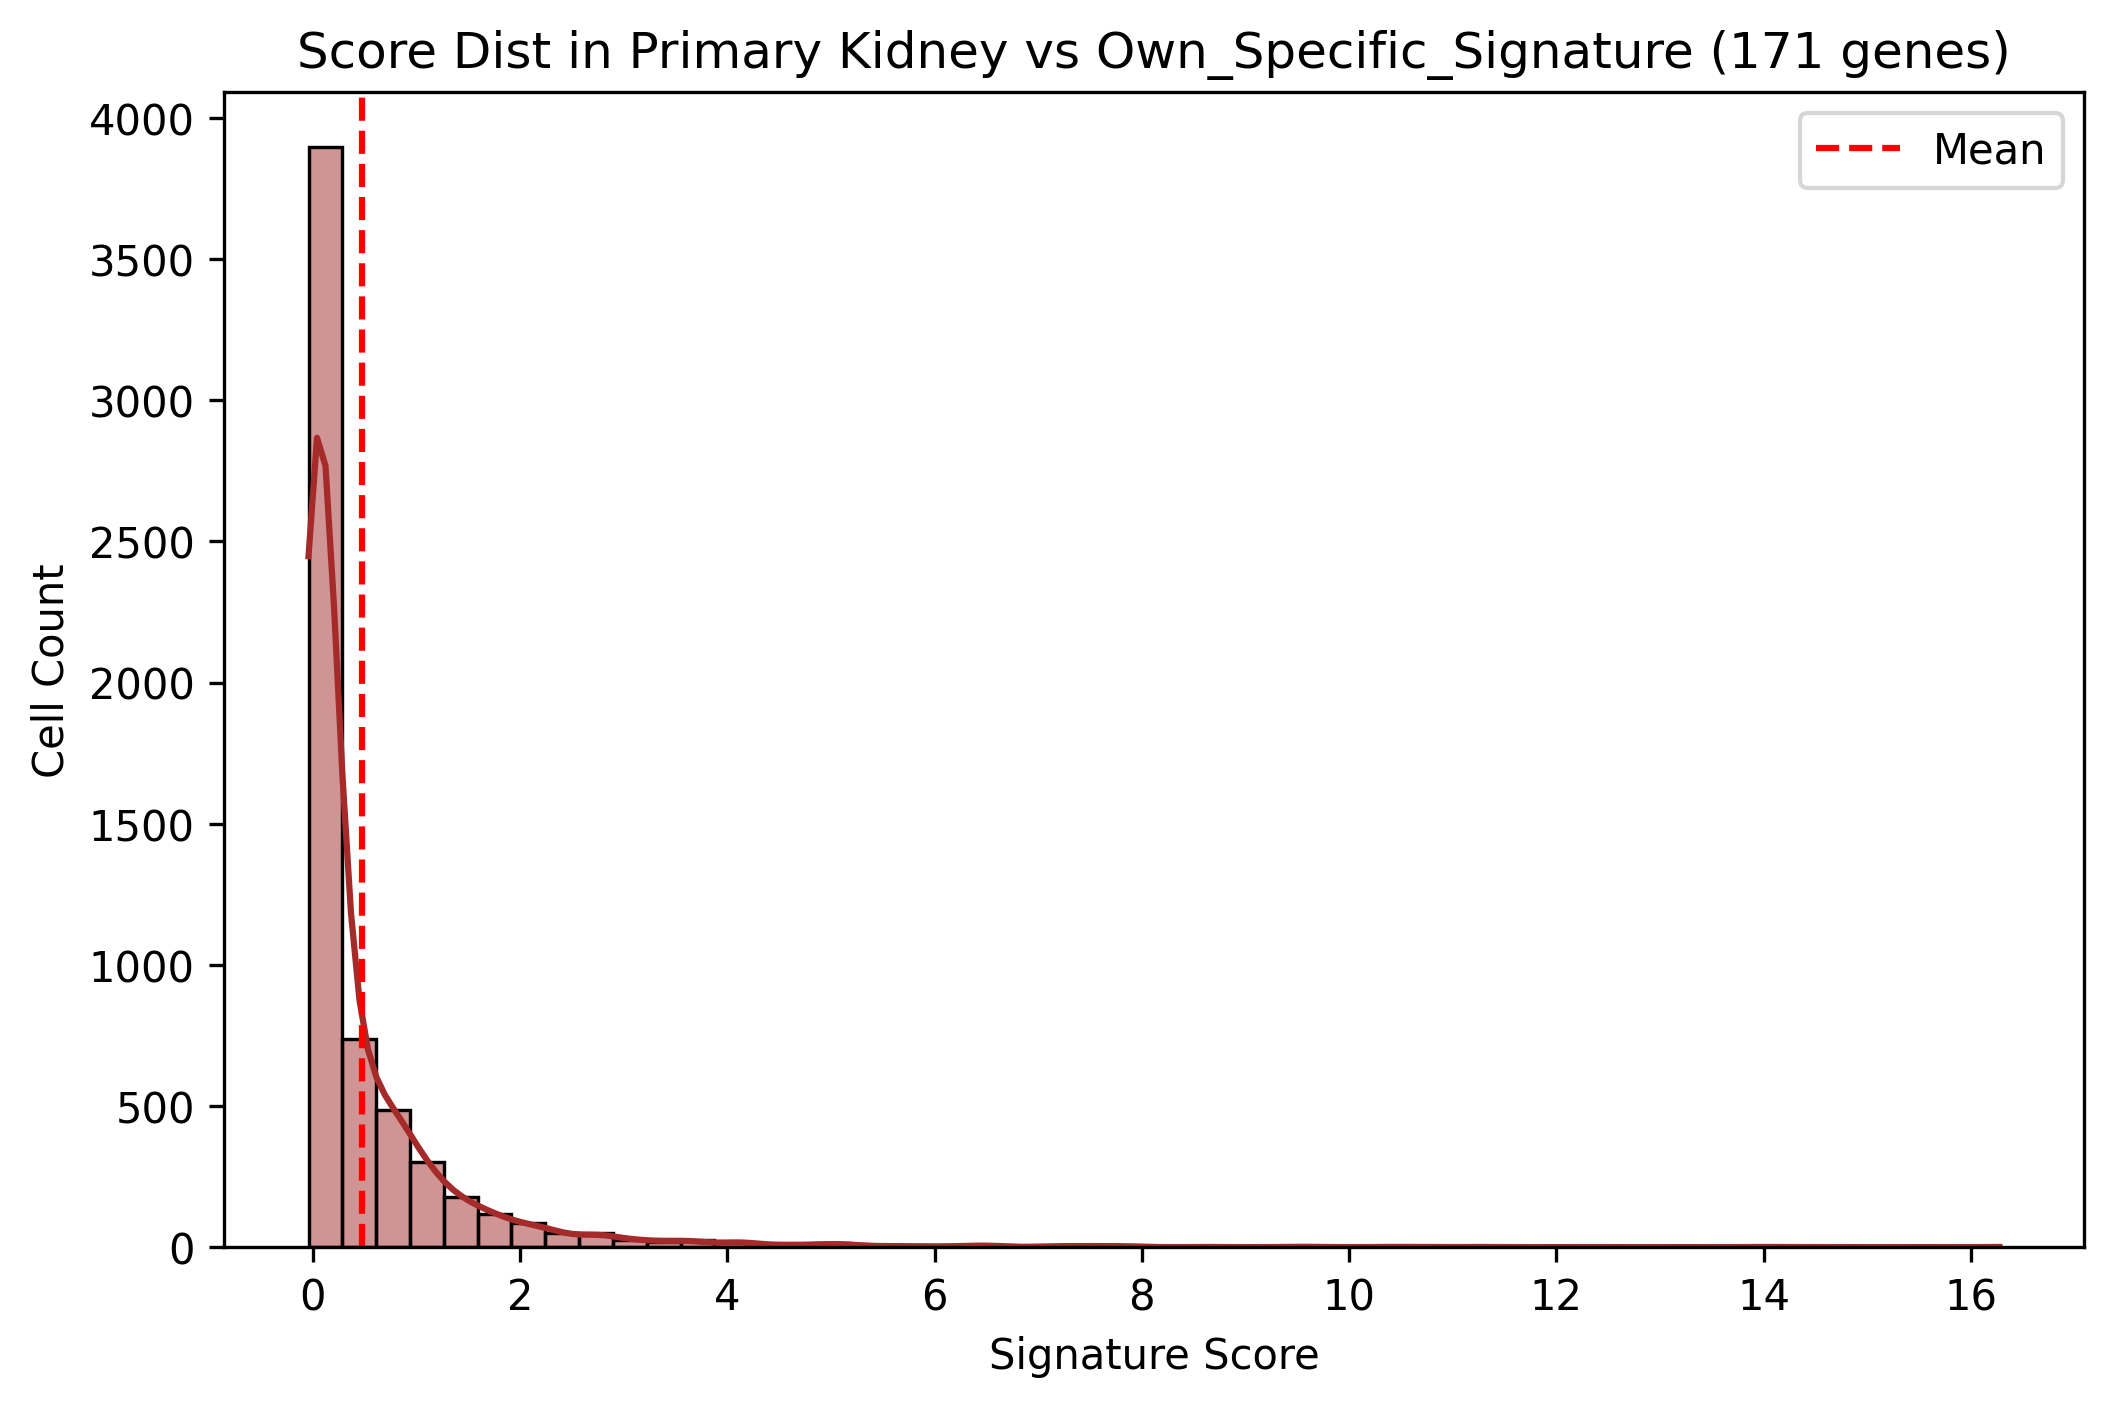

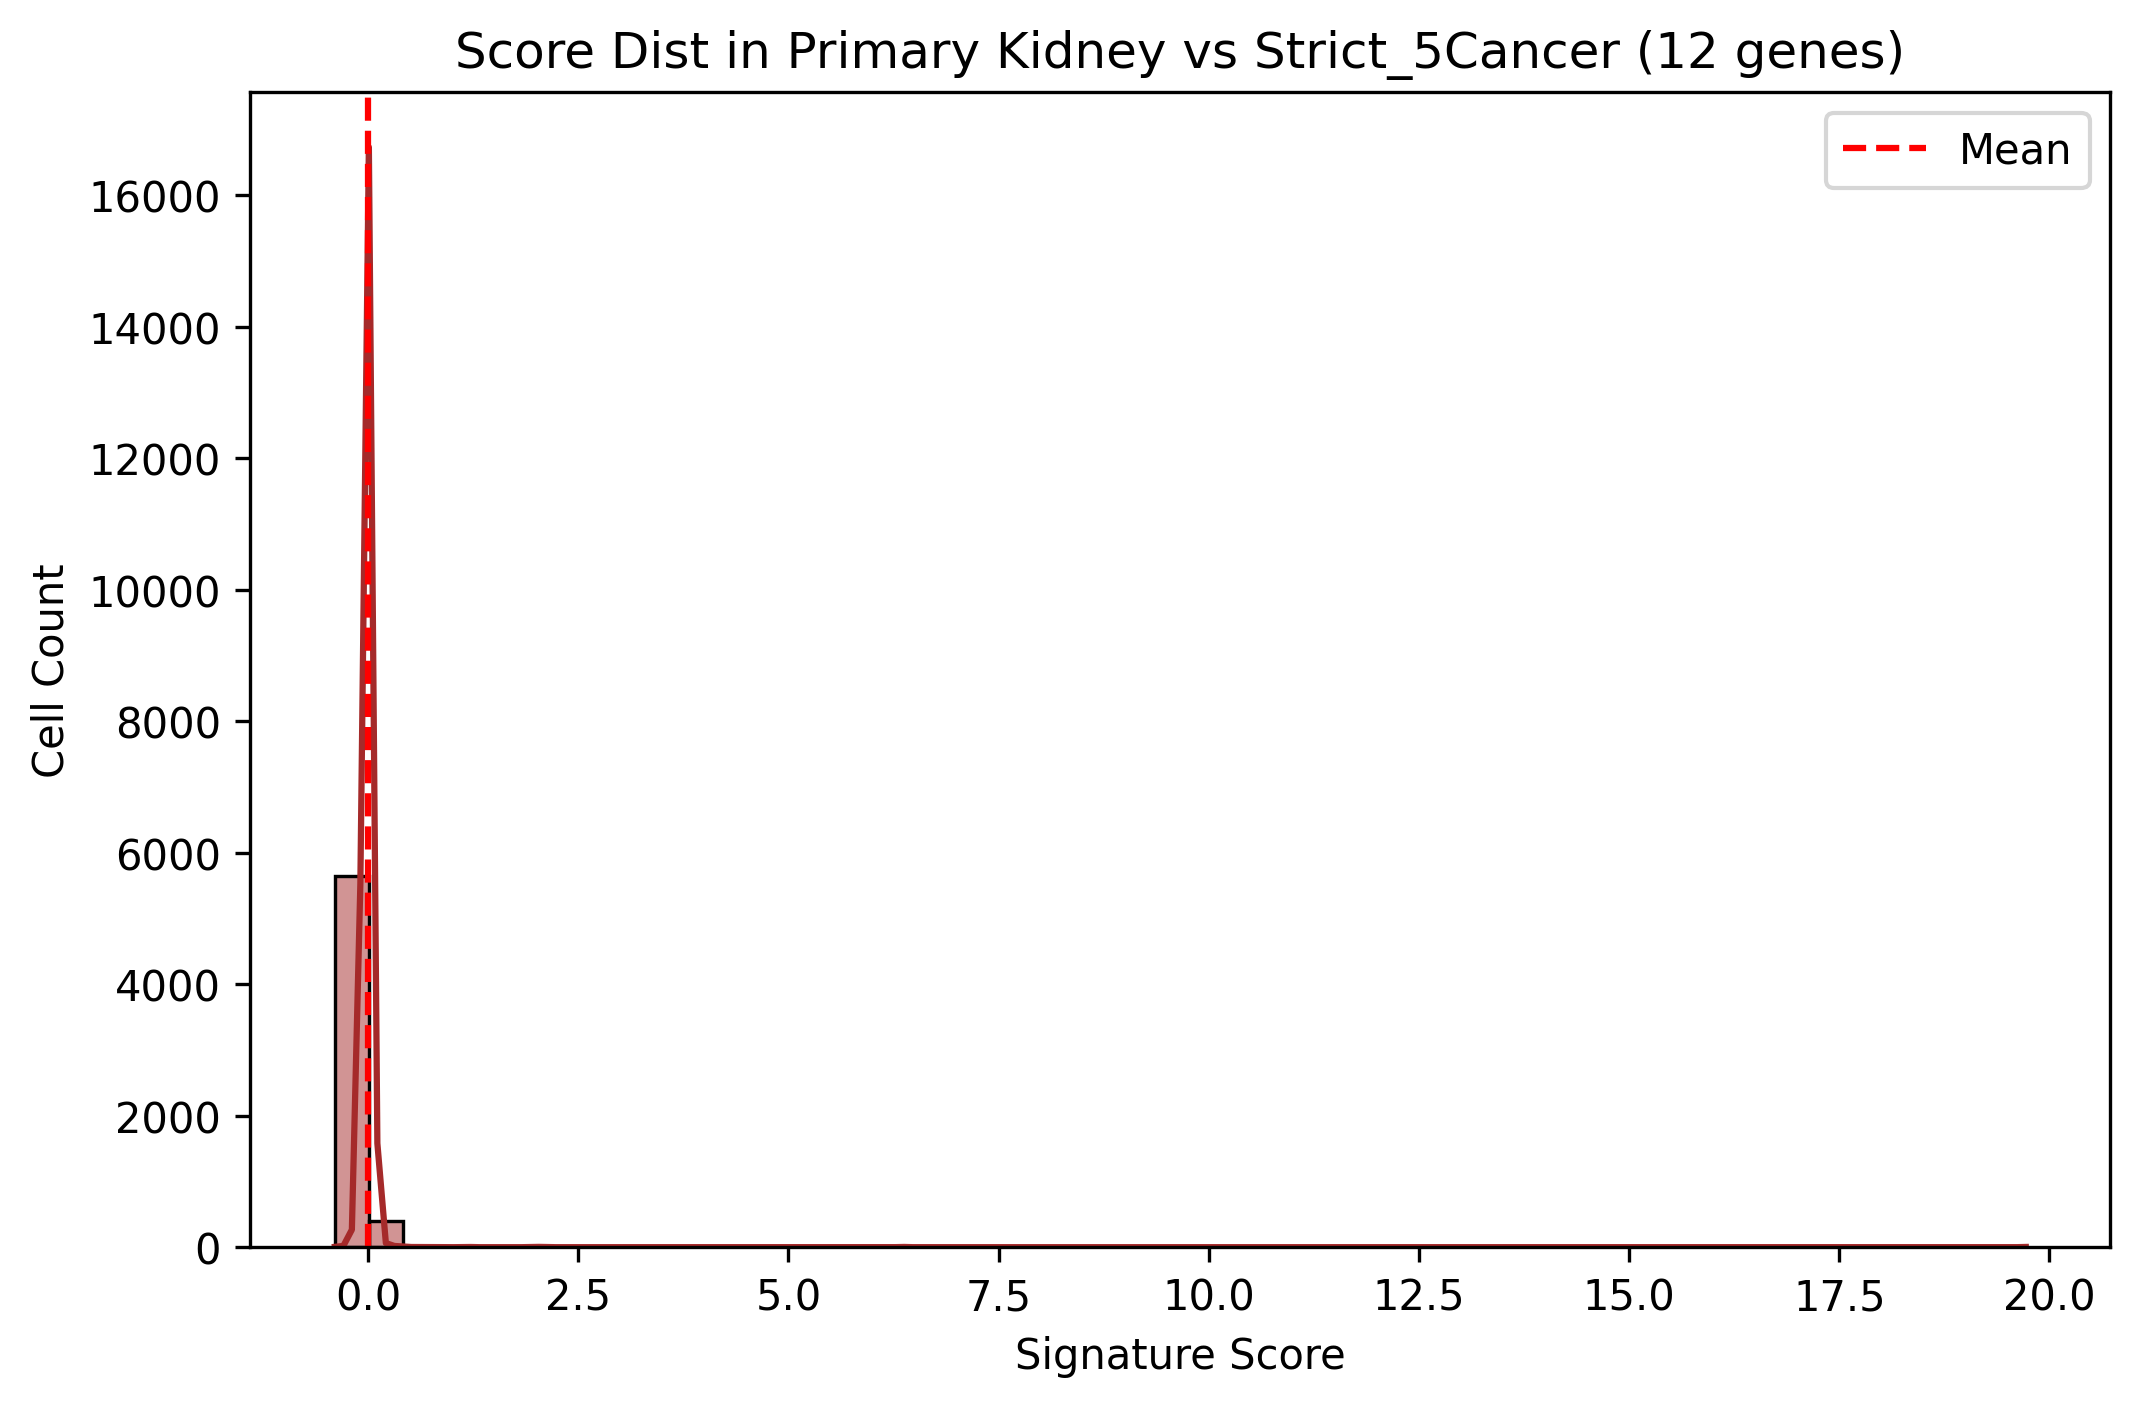

In [ ]:
# 3.5 Ovarian Cancer
import glob
image_paths = glob.glob(os.path.join(META_RESULTS_DIR, f'kidney_primary_score_*.png'))
if not image_paths:
    print(f"Warning: No signature score images found for Ovarian.")
else:
    for ipath in image_paths:
        display(Image(filename=ipath))

# Apply paper recommendations: Identify the rare pre-metastatic subclone using top 5% quantile thresholding
csv_path = os.path.join(META_RESULTS_DIR, f'ovarian_primary_signature_scores{ANALYSIS_SUFFIX}.csv')
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Missing required underlying data CSV: {csv_path}")

df = pd.read_csv(csv_path)

score_cols = [c for c in df.columns if c.startswith('Metastatic_Signature_Score')]
if not score_cols:
    raise ValueError("Missing any 'Metastatic_Signature_Score' columns in CSV data")

print(f"\n--- Subclone Analysis for Ovarian ---")
print(f"Total primary cells: {len(df)}")

for col in score_cols:
    # Avoid hardcoding by calculating threshold computationally
    threshold = df[col].quantile(0.95)
    subclone_df = df[df[col] >= threshold]
    signature_name = col.replace('Metastatic_Signature_Score_', '')
    if signature_name == 'Metastatic_Signature_Score':
        signature_name = 'Conserved Pan-Cancer Signature'
    print(f"\nSignature: {signature_name}")
    print(f"Top 5% Threshold Score: {threshold:.4f}")
    print(f"Identified pre-metastatic subclone cells: {len(subclone_df)}")


#### 3.6 Scoring Primary Kidney Cancer Cells
**Underlying Data (CSV):** `output/pan_cancer_meta_results/kidney_primary_signature_scores{ANALYSIS_SUFFIX}.csv` (contains cell_id, cell_type, tissue, and Metastatic_Signature_Score for every cell plotted below).



--- Subclone Analysis for Kidney ---
Total primary cells: 6056

Signature: Own_Specific_Signature
Top 5% Threshold Score: 2.0550
Identified pre-metastatic subclone cells: 303

Signature: Conserved Pan-Cancer Signature
Top 5% Threshold Score: 0.0518
Identified pre-metastatic subclone cells: 305


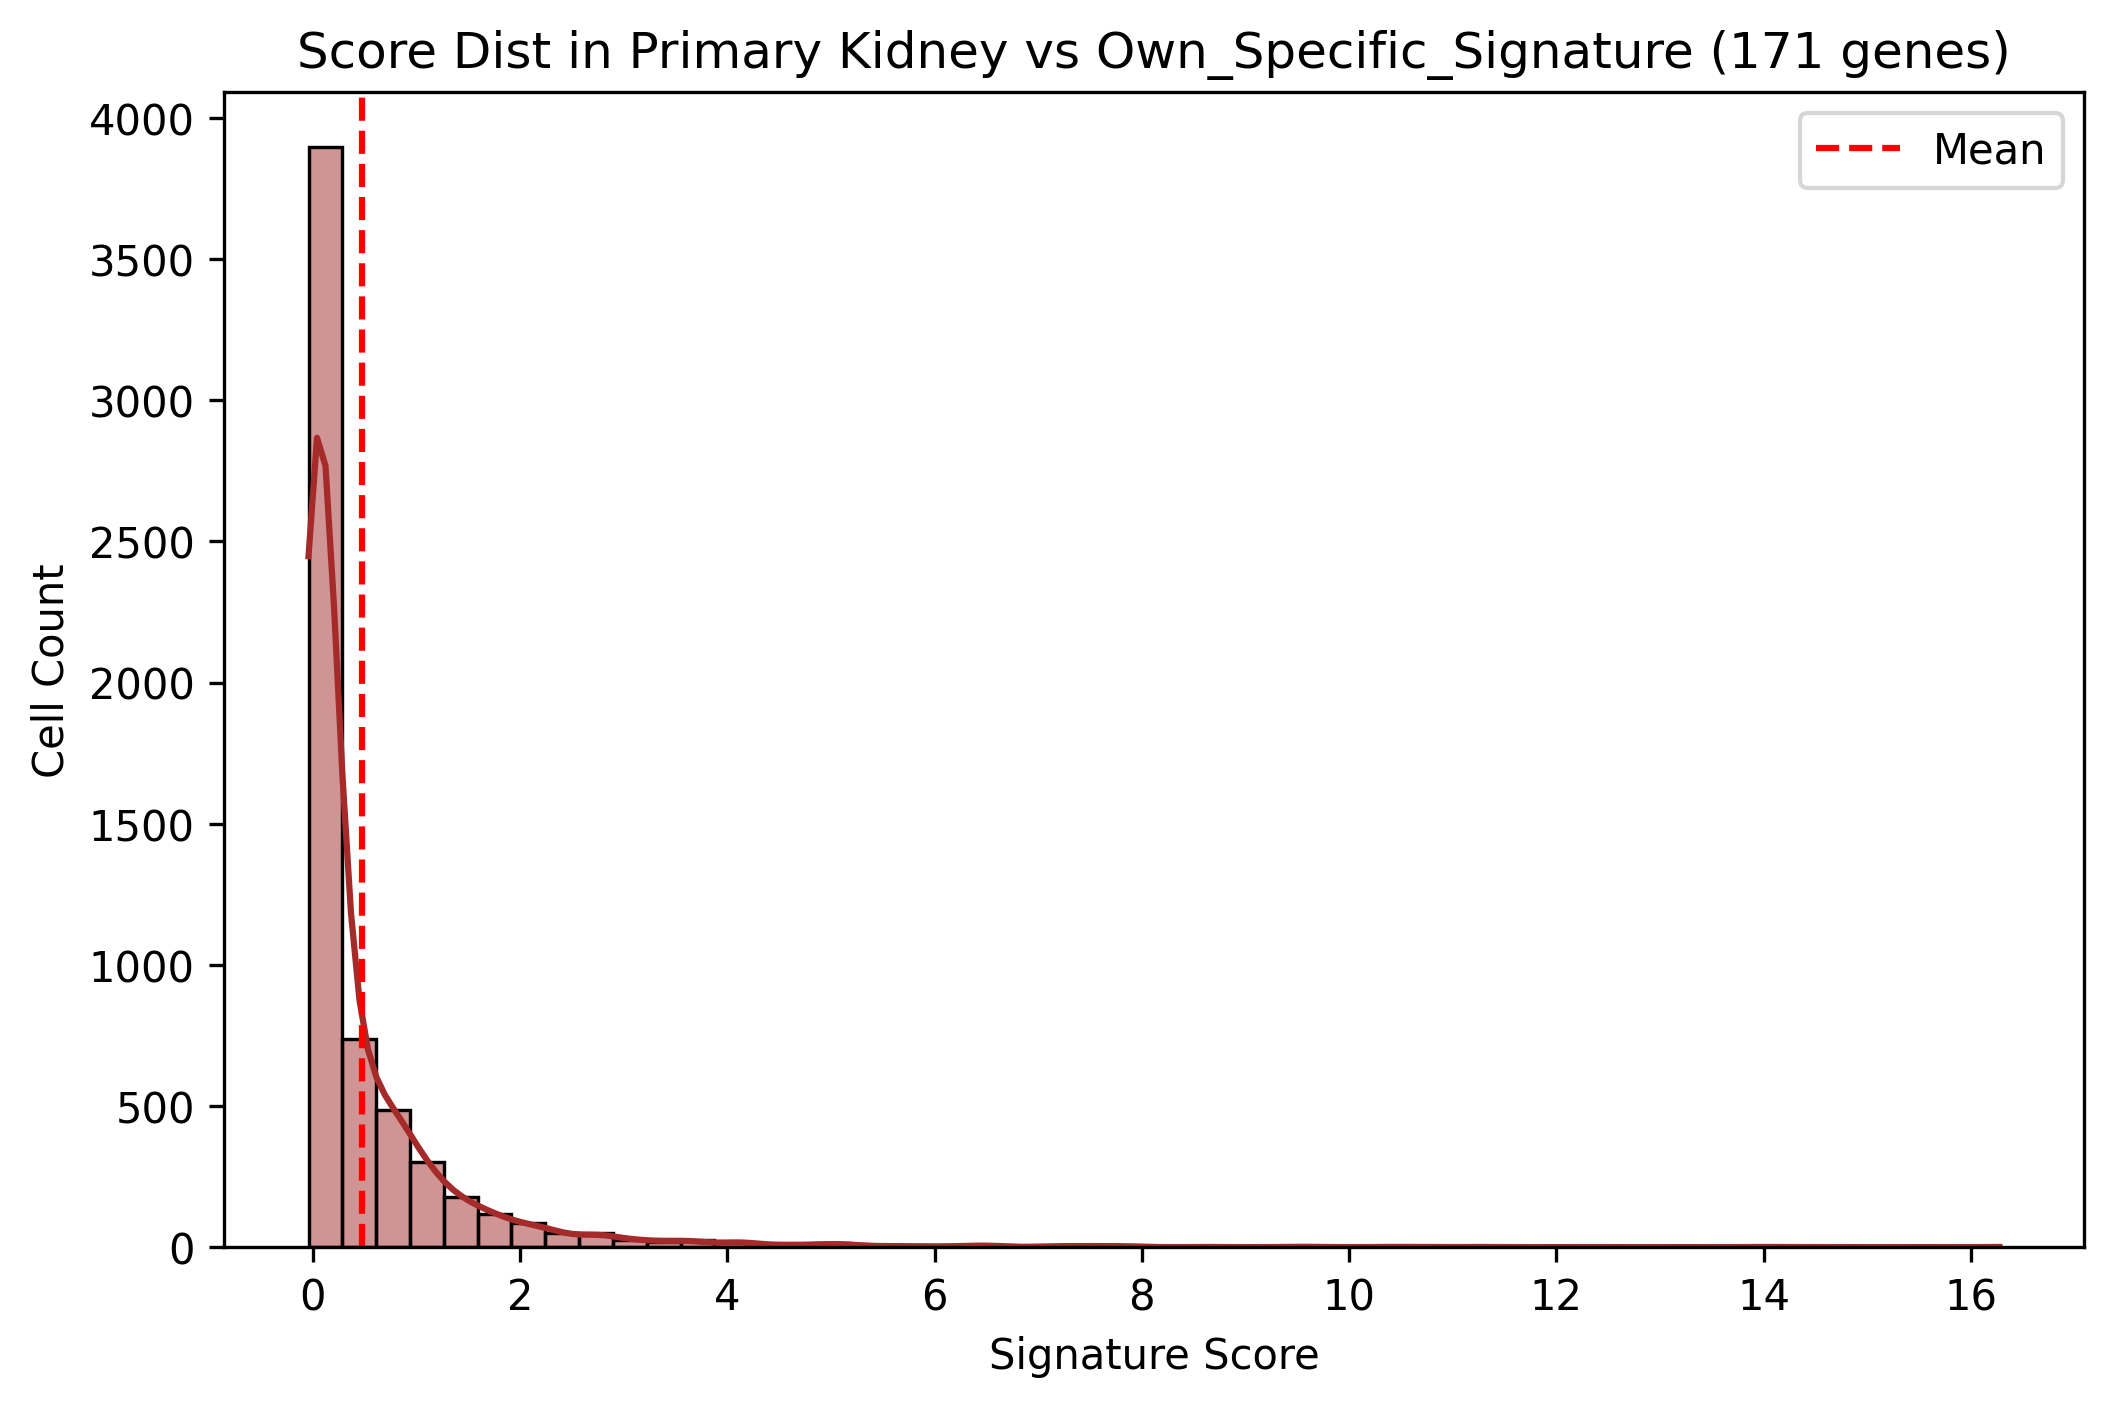

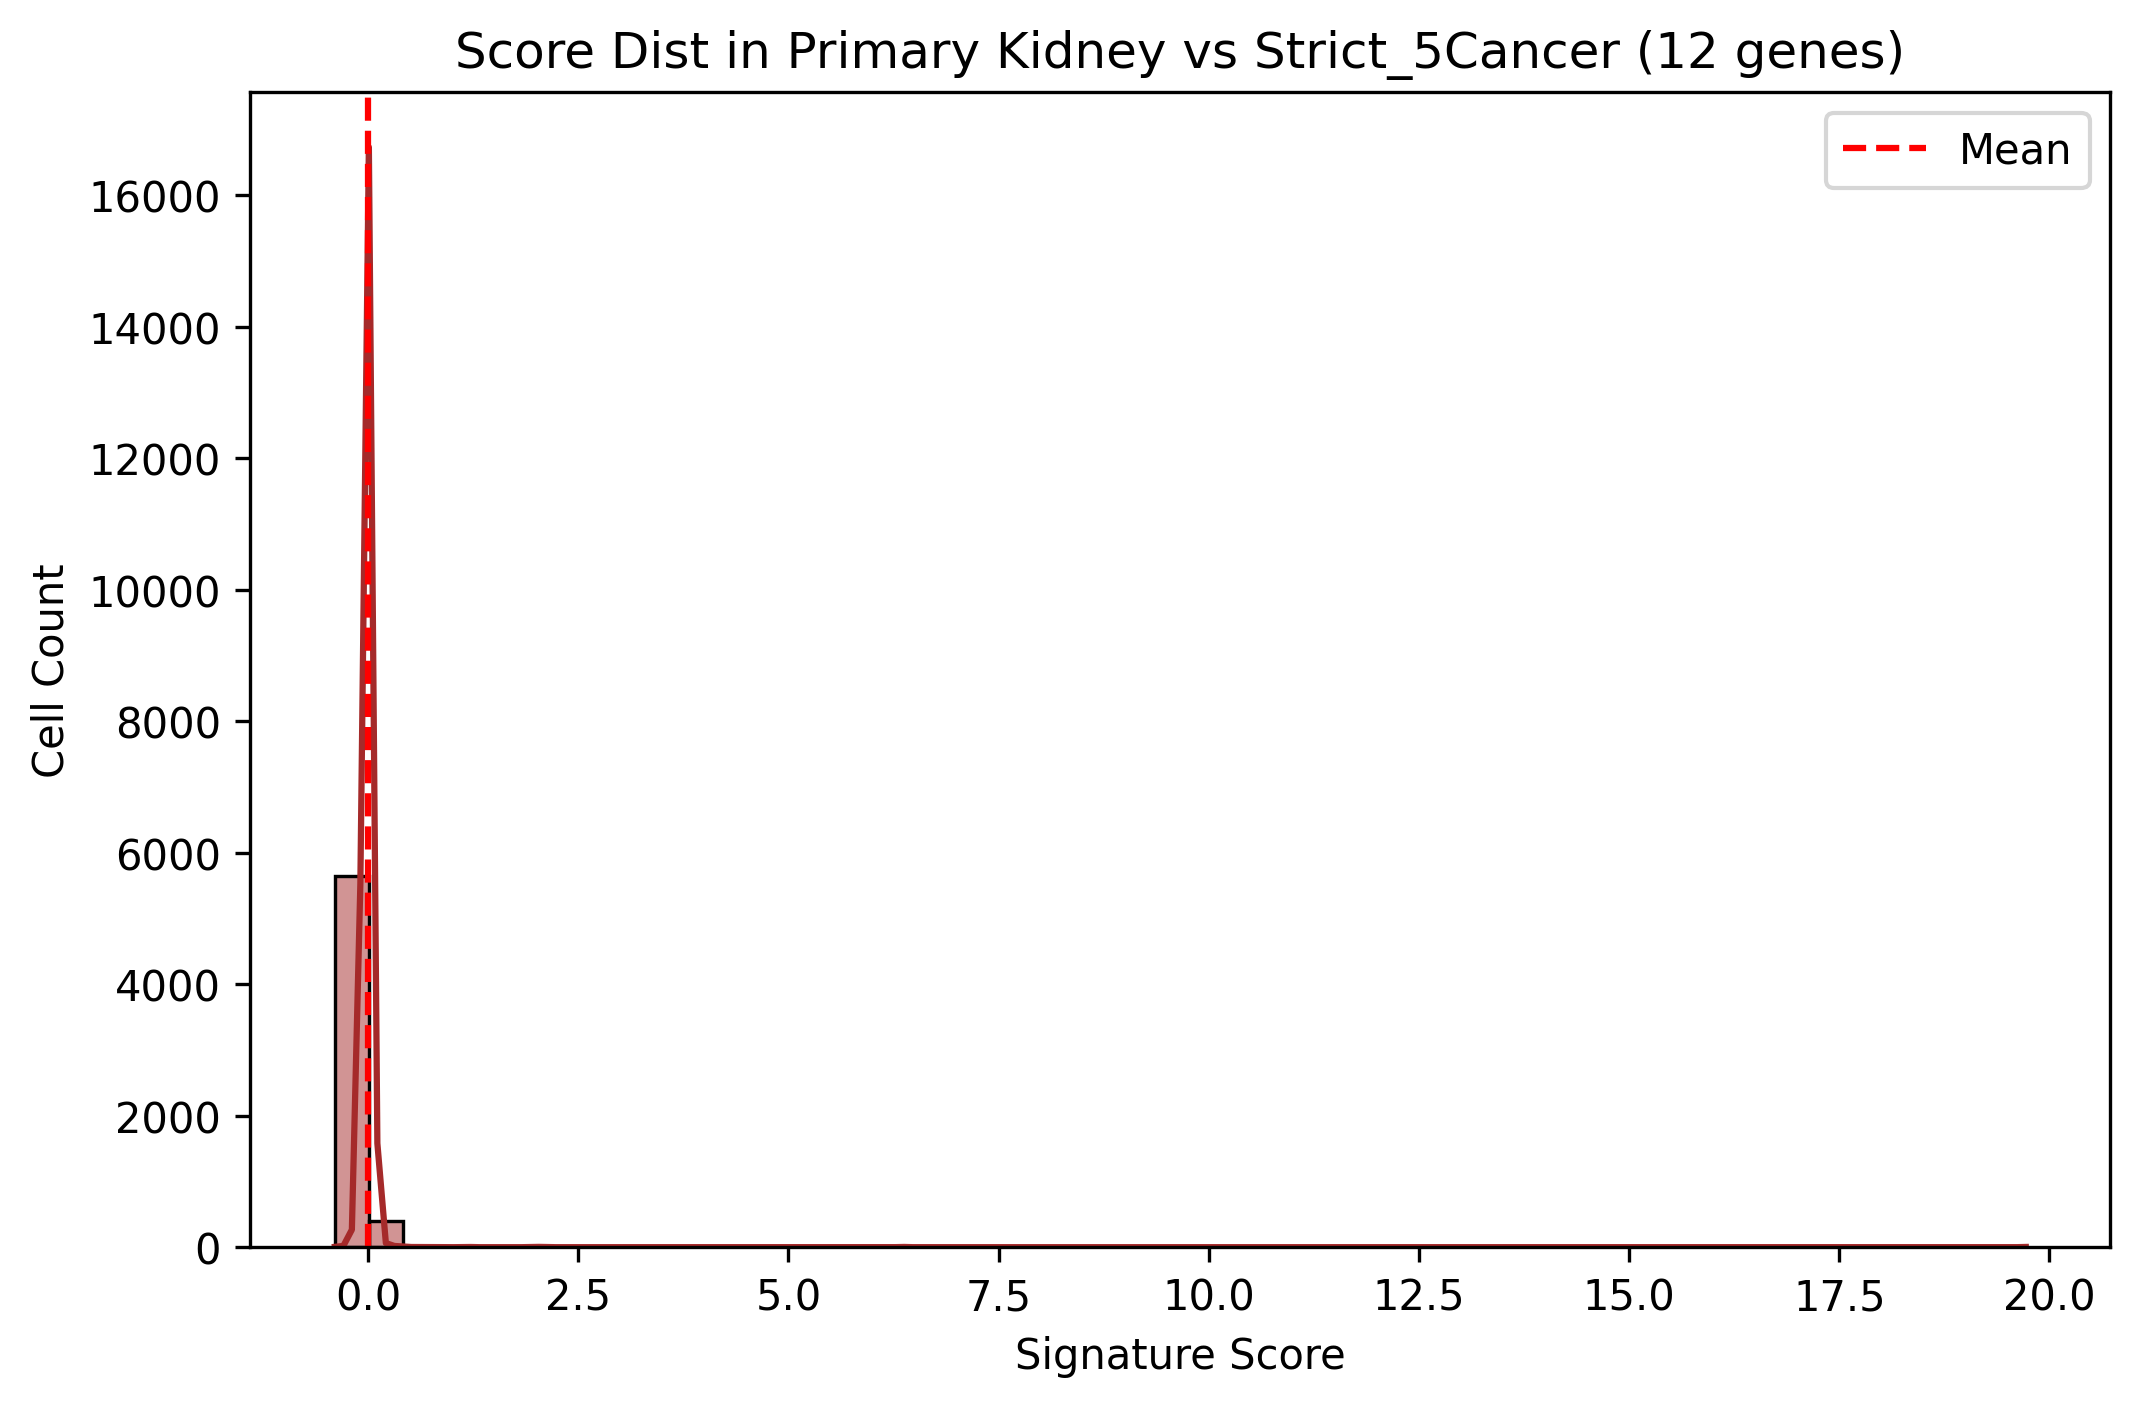

In [ ]:
# 3.6 Kidney Cancer
import glob
image_paths = glob.glob(os.path.join(META_RESULTS_DIR, f'kidney_primary_score_*.png'))
if not image_paths:
    print(f"Warning: No signature score images found for Kidney.")
else:
    for ipath in image_paths:
        display(Image(filename=ipath))

# Apply paper recommendations: Identify the rare pre-metastatic subclone using top 5% quantile thresholding
csv_path = os.path.join(META_RESULTS_DIR, f'kidney_primary_signature_scores{ANALYSIS_SUFFIX}.csv')
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Missing required underlying data CSV: {csv_path}")

df = pd.read_csv(csv_path)

score_cols = [c for c in df.columns if c.startswith('Metastatic_Signature_Score')]
if not score_cols:
    raise ValueError("Missing any 'Metastatic_Signature_Score' columns in CSV data")

print(f"\n--- Subclone Analysis for Kidney ---")
print(f"Total primary cells: {len(df)}")

for col in score_cols:
    # Avoid hardcoding by calculating threshold computationally
    threshold = df[col].quantile(0.95)
    subclone_df = df[df[col] >= threshold]
    signature_name = col.replace('Metastatic_Signature_Score_', '')
    if signature_name == 'Metastatic_Signature_Score':
        signature_name = 'Conserved Pan-Cancer Signature'
    print(f"\nSignature: {signature_name}")
    print(f"Top 5% Threshold Score: {threshold:.4f}")
    print(f"Identified pre-metastatic subclone cells: {len(subclone_df)}")


### 5. Pan-Cancer Immune Evasion & Cell-Cell Communication (CCC)

**Goal:** Quantify the scale of immune evasion and cell-cell communication (CCC) potential across different metastatic niches, and identify strictly conserved ligand-receptor interactions.

**Inputs / Parameters:**
- **CCC Metrics:** `output/pan_cancer_meta_results/immune_evasion_ccc_quantification_6MetCan_{ANALYSIS_SUFFIX}.csv`
- **LIANA Networks:** `output/[cancer]_results/[cancer]_*cellxgene_liana_results.csv`

**Analysis:** We aggregate the CCC quantification outputs from Phase 3 to map the scale of the tumor microenvironment interactome. We then compute the intersection of raw LIANA networks across the analyzed cancers to extract a core, conserved Pan-Cancer CCC Signature.


In [ ]:
# 5. Pan-Cancer Immune Evasion & CCC
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import subprocess
import sys

ccc_csv = os.path.join(META_RESULTS_DIR, f'immune_evasion_ccc_quantification_6MetCan_{ANALYSIS_SUFFIX}.csv')

try:
    df_ccc = pd.read_csv(ccc_csv)
    
    # Plot Total CCC Links and Overlapping Orphans
    fig, ax1 = plt.subplots(figsize=(10, 6))
    sns.barplot(data=df_ccc, x='Cancer', y='Total_Inferred_CCC_Links', ax=ax1, color='lightblue', label='Total CCC Links')
    
    ax2 = ax1.twinx()
    sns.lineplot(data=df_ccc, x='Cancer', y='Overlapping_Orphan_Interactions', ax=ax2, color='darkred', marker='o', linewidth=2, label='Overlapping Orphan Interactions')
    
    ax1.set_ylabel('Total Inferred CCC Links')
    ax2.set_ylabel('Overlapping Orphan Interactions')
    plt.title('Scale of Tumor Microenvironment Interactome Across Cancers')
    
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper right')
    
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"⚠️ Warning: CCC Metrics CSV not found at {ccc_csv}. Ensure Phase 3 has fully completed.")

# Dynamic LIANA Loading and Intersection
print("\n--- Identifying Conserved Pan-Cancer Ligand-Receptor Pairs ---")
liana_datasets = []
valid_cancers = []

for cancer in CANCERS_TO_RUN:
    prefix = cancer.lower()
    if prefix == 'ovary': prefix = 'ovarian'
    search_path = os.path.join(OUTPUT_DIR, f"{prefix}_results", f"{prefix}*cellxgene_liana_results.csv")
    files = glob.glob(search_path)
    
    if not files:
        print(f"⚠️ LIANA CSV missing for {cancer}. Attempting to run fail-safe patch...")
        subprocess.run([sys.executable, os.path.join(BASE_DIR, "scripts", "patch_liana_csvs.py")])
        files = glob.glob(search_path)
        
    if files:
        try:
            df_liana = pd.read_csv(files[0])
            df_liana['interaction_key'] = df_liana['ligand_complex'] + " -> " + df_liana['receptor_complex']
            liana_datasets.append(set(df_liana['interaction_key'].dropna()))
            valid_cancers.append(cancer)
        except Exception as e:
            print(f"⚠️ Error loading LIANA CSV for {cancer}: {e}")
    else:
        print(f"⚠️ Fail-safe failed. LIANA CSV for {cancer} remains missing. Skipping this cancer for intersection.")

if liana_datasets:
    # N-1 Relaxation Logic
    target_overlap = len(valid_cancers)
    conserved_links = set()
    
    while target_overlap > 0:
        # Find elements that appear in at least 'target_overlap' sets
        all_links = set.union(*liana_datasets)
        conserved_links = {link for link in all_links if sum(1 for s in liana_datasets if link in s) >= target_overlap}
        
        if conserved_links:
            print(f"✅ Found {len(conserved_links)} conserved Ligand-Receptor pairs across {target_overlap} out of {len(valid_cancers)} valid cancers.")
            break
        else:
            print(f"⚠️ No conserved pairs found across {target_overlap} cancers. Relaxing threshold...")
            target_overlap -= 1
            
    if conserved_links:
        df_conserved_ccc = pd.DataFrame(list(conserved_links), columns=['Conserved_Ligand_Receptor_Pair'])
        out_path = os.path.join(META_RESULTS_DIR, f'pan_cancer_conserved_ccc_links{ANALYSIS_SUFFIX}.csv')
        df_conserved_ccc.to_csv(out_path, index=False)
        print(f"Exported Conserved CCC links to: {out_path}")
        from IPython.display import display, HTML
        display(HTML(df_conserved_ccc.head(20).to_html()))
else:
    print("❌ No valid LIANA datasets were loaded. Cannot compute intersection.")


⚠️ Warning: CCC Metrics CSV not found at /Users/sakuramaezono/Library/CloudStorage/OneDrive-YokohamaCityUniversity/Personal/05_Python_repositories/metabConnectomeDB/output/pan_cancer_meta_results/immune_evasion_ccc_quantification_6MetCan__6MetCan_500k.csv. Ensure Phase 3 has fully completed.

--- Identifying Conserved Pan-Cancer Ligand-Receptor Pairs ---
✅ Found 1281 conserved Ligand-Receptor pairs across 6 out of 6 valid cancers.
Exported Conserved CCC links to: /Users/sakuramaezono/Library/CloudStorage/OneDrive-YokohamaCityUniversity/Personal/05_Python_repositories/metabConnectomeDB/output/pan_cancer_meta_results/pan_cancer_conserved_ccc_links_6MetCan_500k.csv


,Conserved_Ligand_Receptor_Pair
0,HMGB1 -> TLR2
1,ANGPTL2 -> LILRB3
2,PLTP -> ABCA1
3,FN1 -> ITGA4_ITGB1
4,PSAP -> CELSR1
5,HGF -> NRP1
6,WNT5B -> FZD1_LRP6
7,APP -> GPC1
8,COL18A1 -> PTPRS
9,HLA-DPA1 -> LAG3


In [ ]:
import subprocess
import sys

import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX
notebook_filename = 'pan_cancer_meta_analysis.ipynb'
output_base = 'pan_cancer_meta_analysis' + ANALYSIS_SUFFIX
output_dir = os.path.join('..', 'output', 'pan_cancer_meta_results')
os.makedirs(output_dir, exist_ok=True)

jupyter_bin = os.path.join(os.path.dirname(sys.executable), 'jupyter')
if not os.path.exists(jupyter_bin): jupyter_bin = 'jupyter'

if 'SAVE_AS_HTML' not in locals():
    SAVE_AS_HTML = True

if SAVE_AS_HTML:
    cmd_html = [jupyter_bin, "nbconvert", "--to", "html", "--execute", notebook_filename, "--output-dir", output_dir, "--output", output_base]
    res_html = subprocess.run(cmd_html, capture_output=True, text=True)

    if res_html.returncode == 0:
        print(f"🎉 SUCCESS: Notebook successfully exported to '{os.path.join(output_dir, output_base)}.html'")
    else:
        print("❌ HTML export failed.")
        print(res_html.stderr)
else:
    print("Skipping HTML export to prevent nested nbconvert calls.")
